# Modelo de Previsão de Profundidade de Poços (ARX Multi-Step)

**Pipeline mensal por poço:**
1. Reindexação mensal contínua
2. Imputação de exógenas (rr, eto, caudal)
3. Interpolação de profundidade em gaps curtos (≤3 meses)
4. Split por poço (últimos 12 meses = teste)
5. Treino de XGBoost por poço com features ARX
6. Forecast recursivo de 12 meses

**VERSÃO LIMPA** - sem redundâncias ou código morto

## 1. CONFIGURAÇÃO

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display
import ipywidgets as widgets

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
import joblib

pd.set_option("display.max_columns", 120)

In [2]:
DATA_PATH = Path("mensal_por_poco_full_valores_lags_este.csv")
POCOS = [
    "391/33", "377/94", "330/183", "405/17", "377/86", "341/17", "418/4",
    "391/437", "404/69", "391/243", "342/78", "331/2", "405/34", "390/208",
    "377/54", "342/97", "377/84",
]
EXOG = ["rr", "eto", "caudal"]
LAG_MAX = 2
TEST_MONTHS = 12
INTERP_LIMIT = 3          # máximo de meses consecutivos para interpolar profundidade
MIN_TRAIN_OBS_PER_WELL = 24  # mínimo de observações de treino por poço no rolling-origin

## 2. CARREGAMENTO E FILTRAGEM

In [3]:
print("=" * 80)
print("CARREGAMENTO DE DADOS")
print("=" * 80)

assert DATA_PATH.exists(), f"Arquivo não encontrado: {DATA_PATH}"

df_raw = pd.read_csv(DATA_PATH)
df_raw["ym"] = pd.to_datetime(df_raw["ym"])
df_raw = df_raw.sort_values(["codigo", "ym"]).reset_index(drop=True)
df = df_raw[df_raw["codigo"].isin(POCOS)].reset_index(drop=True)

print(f"\nLinhas totais: {len(df_raw)} | Filtradas: {len(df)}")
print(f"Poços: {len(POCOS)}")
print(f"Período: {df['ym'].min()} → {df['ym'].max()}")

CARREGAMENTO DE DADOS

Linhas totais: 22119 | Filtradas: 5151
Poços: 17
Período: 2000-01-01 00:00:00 → 2025-03-01 00:00:00


## 3. PREPARAÇÃO: REINDEXAÇÃO MENSAL CONTÍNUA

In [4]:
print("\n" + "=" * 80)
print("PREPARAÇÃO: REINDEXAÇÃO MENSAL")
print("=" * 80)

# Manter apenas colunas base (sem lags originais redundantes)
COLS_BASE = ["codigo", "ym", "profundidade", "rr", "eto", "caudal"]
df_work = df[COLS_BASE].copy().sort_values(["codigo", "ym"]).reset_index(drop=True)

# Reindexar para grelha mensal contínua por poço
reindexed = []
for cod, g in df_work.groupby("codigo"):
    full_range = pd.date_range(g["ym"].min(), g["ym"].max(), freq="MS")
    g_reindex = g.set_index("ym").reindex(full_range)
    g_reindex["codigo"] = cod
    g_reindex["ym"] = g_reindex.index
    reindexed.append(g_reindex.reset_index(drop=True))

df_monthly = pd.concat(reindexed, ignore_index=True)
print(f"\nApós reindexação: {df_monthly.shape}")
print(f"NaNs em profundidade: {df_monthly['profundidade'].isna().sum()} "
      f"({df_monthly['profundidade'].isna().mean()*100:.1f}%)")


PREPARAÇÃO: REINDEXAÇÃO MENSAL

Após reindexação: (5151, 6)
NaNs em profundidade: 2677 (52.0%)


## 4. PREPARAÇÃO: IMPUTAÇÃO DE EXÓGENAS

In [5]:
print("\n" + "=" * 80)
print("IMPUTAÇÃO DE EXÓGENAS (rr, eto, caudal)")
print("=" * 80)

print(f"\nNaNs ANTES: {df_monthly[EXOG].isna().sum().to_dict()}")

# Interpolação linear curta + ffill/bfill por poço
filled_parts = []
for cod, g in df_monthly.groupby("codigo"):
    g = g.copy()
    g[EXOG] = g[EXOG].interpolate(method="linear", limit=INTERP_LIMIT, limit_direction="both")
    g[EXOG] = g[EXOG].ffill().bfill()
    filled_parts.append(g)

df_monthly = pd.concat(filled_parts, ignore_index=True)

# Fallback: mediana global
for col in EXOG:
    if df_monthly[col].isna().any():
        df_monthly[col] = df_monthly[col].fillna(df_monthly[col].median())

print(f"NaNs DEPOIS: {df_monthly[EXOG].isna().sum().sum()} (esperado: 0)")


IMPUTAÇÃO DE EXÓGENAS (rr, eto, caudal)

NaNs ANTES: {'rr': 51, 'eto': 51, 'caudal': 136}
NaNs DEPOIS: 0 (esperado: 0)


## 5. PREPARAÇÃO: LAGS EXÓGENOS

In [6]:
print("\n" + "=" * 80)
print("CRIAÇÃO DE LAGS EXÓGENOS")
print("=" * 80)

for col in EXOG:
    for lag in range(1, LAG_MAX + 1):
        df_monthly[f"{col}_lag{lag}"] = df_monthly.groupby("codigo")[col].shift(lag)

exog_lag_cols = [f"{c}_lag{i}" for c in EXOG for i in range(1, LAG_MAX + 1)]
print(f"\nLags criados: {exog_lag_cols}")


CRIAÇÃO DE LAGS EXÓGENOS

Lags criados: ['rr_lag1', 'rr_lag2', 'eto_lag1', 'eto_lag2', 'caudal_lag1', 'caudal_lag2']


## 6. PREPARAÇÃO: INTERPOLAÇÃO DE PROFUNDIDADE

In [7]:
print("\n" + "=" * 80)
print("INTERPOLAÇÃO DE PROFUNDIDADE (gaps ≤3 meses internos)")
print("=" * 80)

# Guardar valores originais
df_monthly["prof_original"] = df_monthly["profundidade"].copy()

print(f"\nNaN ANTES: {df_monthly['profundidade'].isna().sum()} "
      f"({df_monthly['profundidade'].isna().mean()*100:.1f}%)")

# Interpolação por poço (apenas gaps internos)
interpolated_rows = []
for cod, g in df_monthly.groupby("codigo"):
    g = g.sort_values("ym").copy()
    s = g.set_index("ym")["profundidade"]
    s_interp = s.interpolate(
        method="time",
        limit=INTERP_LIMIT,
        limit_direction="both",
        limit_area="inside"  # Apenas gaps internos
    )
    g["profundidade"] = s_interp.values
    interpolated_rows.append(g)

df_monthly = pd.concat(interpolated_rows, ignore_index=True)

n_interpolated = ((df_monthly["prof_original"].isna()) & 
                  (df_monthly["profundidade"].notna())).sum()
print(f"Valores interpolados: {n_interpolated}")
print(f"NaN DEPOIS: {df_monthly['profundidade'].isna().sum()} "
      f"({df_monthly['profundidade'].isna().mean()*100:.1f}%)")


INTERPOLAÇÃO DE PROFUNDIDADE (gaps ≤3 meses internos)

NaN ANTES: 2677 (52.0%)
Valores interpolados: 630
NaN DEPOIS: 2047 (39.7%)


## 7. PREPARAÇÃO: FEATURES TEMPORAIS E LAGS DO ALVO

In [8]:
print("\n" + "=" * 80)
print("FEATURES TEMPORAIS E LAGS DO ALVO")
print("=" * 80)

# Sazonalidade
df_monthly["mes"] = df_monthly["ym"].dt.month
df_monthly["mes_sin"] = np.sin(2 * np.pi * df_monthly["mes"] / 12)
df_monthly["mes_cos"] = np.cos(2 * np.pi * df_monthly["mes"] / 12)

# Lags do alvo (agora com profundidade interpolada)
df_monthly["profundidade_lag1"] = df_monthly.groupby("codigo")["profundidade"].shift(1)
df_monthly["profundidade_lag2"] = df_monthly.groupby("codigo")["profundidade"].shift(2)

print(f"\nShape após features: {df_monthly.shape}")


FEATURES TEMPORAIS E LAGS DO ALVO

Shape após features: (5151, 18)


## 8. PREPARAÇÃO: REMOVER BORDAS DE LAGS

In [9]:
print("\n" + "=" * 80)
print("REMOÇÃO DE BORDAS (2 primeiras linhas/poço)")
print("=" * 80)

# Remover as 2 primeiras linhas de cada poço (borda dos lags)
# Usando assign + loc para não perder a coluna 'codigo'
df_clean = (
    df_monthly
    .sort_values(["codigo", "ym"])
    .assign(_rn=lambda d: d.groupby("codigo").cumcount())
    .loc[lambda d: d["_rn"] >= 2]
    .drop(columns=["_rn"])
    .reset_index(drop=True)
)

print(f"\nShape final: {df_clean.shape}")
print(f"✓ Tem coluna 'codigo': {'codigo' in df_clean.columns}")
print(f"NaNs em lags exógenos: {df_clean[exog_lag_cols].isna().sum().sum()}")
print(f"NaNs em profundidade_lag1/2: {df_clean[['profundidade_lag1','profundidade_lag2']].isna().sum().to_dict()}")


REMOÇÃO DE BORDAS (2 primeiras linhas/poço)

Shape final: (5117, 18)
✓ Tem coluna 'codigo': True
NaNs em lags exógenos: 0
NaNs em profundidade_lag1/2: {'profundidade_lag1': 2024, 'profundidade_lag2': 2013}


## 9. DEFINIÇÃO DE FEATURES E BASES

In [10]:
print("\n" + "=" * 80)
print("DEFINIÇÃO DE FEATURES E BASES")
print("=" * 80)

# Features do modelo ARX
feature_cols = []
feature_cols += exog_lag_cols  # lags exógenos (rr, eto, caudal: lag1-2)
feature_cols += ["profundidade_lag1", "profundidade_lag2"]  # lags do alvo
feature_cols += ["mes_sin", "mes_cos"]  # sazonalidade

print(f"\nFeatures do modelo ({len(feature_cols)}): {feature_cols}")

# Base mensal completa (para forecast recursivo)
df_model_base = df_clean.copy()

# Linhas treináveis: profundidade + lags do alvo presentes (necessário para ARX)
df_trainable = df_model_base.dropna(
    subset=["profundidade", "profundidade_lag1", "profundidade_lag2"]
).copy()

print(f"\ndf_model_base (mensal completo): {df_model_base.shape}")
print(f"df_trainable (com alvo+lags): {df_trainable.shape}")
print(f"  → Inclui {(df_trainable['prof_original'].isna()).sum()} meses com profundidade interpolada")


DEFINIÇÃO DE FEATURES E BASES

Features do modelo (10): ['rr_lag1', 'rr_lag2', 'eto_lag1', 'eto_lag2', 'caudal_lag1', 'caudal_lag2', 'profundidade_lag1', 'profundidade_lag2', 'mes_sin', 'mes_cos']

df_model_base (mensal completo): (5117, 18)
df_trainable (com alvo+lags): (2994, 18)
  → Inclui 553 meses com profundidade interpolada


## 10. EXPORTAR BASES

In [11]:
Path("exports_csv").mkdir(exist_ok=True)
df_trainable.to_csv("exports_csv/df_model_base_full.csv", index=False)
print("\n✓ Exportado: exports_csv/df_model_base_full.csv")


✓ Exportado: exports_csv/df_model_base_full.csv


## 11. SPLIT TEMPORAL POR POÇO

In [12]:
print("\n" + "=" * 80)
print("SPLIT TEMPORAL (últimos 12 meses = teste)")
print("=" * 80)


SPLIT TEMPORAL (últimos 12 meses = teste)


In [13]:
def make_train_test_split(df_full, df_trainable, feature_cols, test_months=TEST_MONTHS):
    """
    Split por poço: últimos test_months = teste
    
    Retorna:
    - df_train_full, df_test_full: grelha mensal completa (para forecast)
    - df_train_eval, df_test_eval: só linhas treináveis (para métricas)
    - X_train, y_train, X_test, y_test: arrays prontos para treino
    """
    train_full, test_full = [], []
    train_eval, test_eval = [], []
    
    for cod in df_full["codigo"].unique():
        g_full = df_full[df_full["codigo"] == cod].copy()
        g_trainable = df_trainable[df_trainable["codigo"] == cod].copy()
        
        if g_trainable.empty:
            print(f"  ⚠️  Poço {cod}: sem dados treináveis")
            continue
        
        # Última observação válida (para definir cutoff)
        last_valid_date = g_trainable["ym"].max()
        cutoff = last_valid_date - pd.DateOffset(months=test_months - 1)
        
        # Split na grelha completa
        g_full_truncated = g_full[g_full["ym"] <= last_valid_date].copy()
        train_full.append(g_full_truncated[g_full_truncated["ym"] < cutoff])
        test_full.append(g_full_truncated[g_full_truncated["ym"] >= cutoff])
        
        # Split nas linhas treináveis
        train_eval.append(g_trainable[g_trainable["ym"] < cutoff])
        test_eval.append(g_trainable[g_trainable["ym"] >= cutoff])
    
    df_train_full = pd.concat(train_full, ignore_index=True) if train_full else pd.DataFrame()
    df_test_full = pd.concat(test_full, ignore_index=True) if test_full else pd.DataFrame()
    df_train_eval = pd.concat(train_eval, ignore_index=True) if train_eval else pd.DataFrame()
    df_test_eval = pd.concat(test_eval, ignore_index=True) if test_eval else pd.DataFrame()
    
    # Preparar X, y
    X_train = df_train_eval[feature_cols].copy()
    y_train = df_train_eval["profundidade"].copy()
    X_test = df_test_eval[feature_cols].copy()
    y_test = df_test_eval["profundidade"].copy()
    
    return df_train_full, df_test_full, df_train_eval, df_test_eval, X_train, y_train, X_test, y_test

In [14]:
(
    df_train_full, df_test_full,
    df_train_eval, df_test_eval,
    X_train, y_train,
    X_test, y_test
) = make_train_test_split(df_model_base, df_trainable, feature_cols, TEST_MONTHS)

print(f"\nTreino: {df_train_eval.shape} obs | Teste: {df_test_eval.shape} obs")
print(f"X_train: {X_train.shape}, y_train: {len(y_train)}")
print(f"X_test: {X_test.shape}, y_test: {len(y_test)}")
print(f"\n✓ NaNs em X_train: {X_train.isna().sum().sum()}")
print(f"✓ NaNs em X_test: {X_test.isna().sum().sum()}")

# Resumo por poço
summary_rows = []
for cod in sorted(df_train_eval["codigo"].unique()):
    gtr = df_train_eval[df_train_eval["codigo"] == cod]
    gte = df_test_eval[df_test_eval["codigo"] == cod]
    summary_rows.append({
        "codigo": cod,
        "train_start": gtr["ym"].min(),
        "train_end": gtr["ym"].max(),
        "train_n": len(gtr),
        "test_start": gte["ym"].min() if not gte.empty else pd.NaT,
        "test_end": gte["ym"].max() if not gte.empty else pd.NaT,
        "test_n": len(gte),
    })

# Exportar CSVs primeiro
df_train_eval.to_csv("exports_csv/df_train_eval.csv", index=False)
df_test_eval.to_csv("exports_csv/df_test_eval.csv", index=False)
df_train_full.to_csv("exports_csv/df_train_local_full.csv", index=False)
df_test_full.to_csv("exports_csv/df_test_local_full.csv", index=False)
print("\n✓ Exportados: df_train_eval, df_test_eval, df_train_local_full, df_test_local_full")

# Criar e exibir tabela de resumo
df_summary = pd.DataFrame(summary_rows)
print("\n" + "=" * 80)
print("RESUMO DOS PERÍODOS DE TREINO E TESTE POR POÇO")
print("=" * 80)
df_summary


Treino: (2790, 18) obs | Teste: (204, 18) obs
X_train: (2790, 10), y_train: 2790
X_test: (204, 10), y_test: 204

✓ NaNs em X_train: 0
✓ NaNs em X_test: 0

✓ Exportados: df_train_eval, df_test_eval, df_train_local_full, df_test_local_full

RESUMO DOS PERÍODOS DE TREINO E TESTE POR POÇO


,codigo,train_start,train_end,train_n,test_start,test_end,test_n
0,330/183,2000-03-01,2024-01-01,267,2024-02-01,2025-01-01,12
1,331/2,2017-01-01,2023-06-01,78,2023-07-01,2024-06-01,12
2,341/17,2000-03-01,2023-06-01,249,2023-07-01,2024-06-01,12
3,342/78,2000-03-01,2010-07-01,101,2010-08-01,2011-07-01,12
4,342/97,2000-03-01,2007-03-01,65,2007-04-01,2008-03-01,12
5,377/54,2017-12-01,2023-06-01,67,2023-07-01,2024-06-01,12
6,377/84,2017-12-01,2020-12-01,37,2021-01-01,2021-12-01,12
7,377/86,2002-08-01,2024-01-01,238,2024-02-01,2025-01-01,12
8,377/94,2000-03-01,2024-01-01,275,2024-02-01,2025-01-01,12
9,390/208,2017-12-01,2023-06-01,67,2023-07-01,2024-06-01,12


## 11.5. VALIDAÇÃO ROLLING-ORIGIN (RETROSPETIVA)

Validação com múltiplos splits temporais (k = 0, 1, 2, ...) andando para trás no tempo.
Para cada k:
- Recua o fim do histórico k meses
- Re-treina os modelos com (n-k) observações
- Gera previsões de 12 meses
- Calcula métricas (RMSE, MAE, R²)

Critério de paragem: quando o tamanho do treino fica < 50% do original ou abaixo de um mínimo.

In [15]:
print("\n" + "=" * 80)
print("VALIDAÇÃO ROLLING-ORIGIN: SETUP")
print("=" * 80)

# Verificar se as variáveis necessárias existem
required_vars = {
    'df_model_base': 'DataFrame com grelha mensal completa',
    'df_trainable': 'DataFrame com linhas treináveis',
    'feature_cols': 'Lista de features do modelo',
    'TEST_MONTHS': 'Número de meses para teste'
}

missing_vars = []
for var_name, var_desc in required_vars.items():
    if var_name not in globals():
        missing_vars.append(f"  - {var_name}: {var_desc}")

if missing_vars:
    print("\n❌ ERRO: Variáveis necessárias não estão definidas:")
    print("\n".join(missing_vars))
    print("\n⚠️  SOLUÇÃO: Execute TODAS as células anteriores (secções 1-11) antes desta secção.")
    raise NameError("Variáveis necessárias não definidas. Execute células anteriores primeiro.")

print("\n✓ Todas as variáveis necessárias estão disponíveis")
print(f"  - df_model_base: {df_model_base.shape}")
print(f"  - df_trainable: {df_trainable.shape}")
print(f"  - feature_cols: {len(feature_cols)} features")
print(f"  - TEST_MONTHS: {TEST_MONTHS}")


VALIDAÇÃO ROLLING-ORIGIN: SETUP

✓ Todas as variáveis necessárias estão disponíveis
  - df_model_base: (5117, 18)
  - df_trainable: (2994, 18)
  - feature_cols: 10 features
  - TEST_MONTHS: 12


In [16]:
def make_train_test_split_with_offset(df_full, df_trainable, feature_cols, test_months=TEST_MONTHS, k_offset=0, min_train_obs_per_well=MIN_TRAIN_OBS_PER_WELL):
    """
    Split por poço com offset k (recua k meses no tempo).
    
    k_offset=0: comportamento normal (últimos 12 meses = teste)
    k_offset=1: recua 1 mês (penúltimo ano completo)
    k_offset=k: recua k meses
    
    min_train_obs_per_well: mínimo de observações de treino por poço (critério individual).
    Poços que ficam abaixo deste limiar para um dado k são excluídos nesse k.
    
    Retorna os mesmos outputs que make_train_test_split original.
    """
    train_full, test_full = [], []
    train_eval, test_eval = [], []
    
    for cod in df_full["codigo"].unique():
        g_full = df_full[df_full["codigo"] == cod].copy()
        g_trainable = df_trainable[df_trainable["codigo"] == cod].copy()
        
        if g_trainable.empty:
            continue
        
        # Última observação válida MENOS k_offset meses
        last_valid_date = g_trainable["ym"].max() - pd.DateOffset(months=k_offset)
        
        # Verificar se ainda há dados suficientes após o offset
        g_trainable_truncated = g_trainable[g_trainable["ym"] <= last_valid_date]
        if g_trainable_truncated.empty:
            continue
        
        cutoff = last_valid_date - pd.DateOffset(months=test_months - 1)
        
        # Critério por poço: mínimo de observações de treino individuais
        train_part = g_trainable_truncated[g_trainable_truncated["ym"] < cutoff]
        if len(train_part) < min_train_obs_per_well:
            continue
        
        # Split na grelha completa
        g_full_truncated = g_full[g_full["ym"] <= last_valid_date].copy()
        train_full.append(g_full_truncated[g_full_truncated["ym"] < cutoff])
        test_full.append(g_full_truncated[g_full_truncated["ym"] >= cutoff])
        
        # Split nas linhas treináveis
        train_eval.append(train_part)
        test_eval.append(g_trainable_truncated[g_trainable_truncated["ym"] >= cutoff])
    
    df_train_full = pd.concat(train_full, ignore_index=True) if train_full else pd.DataFrame()
    df_test_full = pd.concat(test_full, ignore_index=True) if test_full else pd.DataFrame()
    df_train_eval = pd.concat(train_eval, ignore_index=True) if train_eval else pd.DataFrame()
    df_test_eval = pd.concat(test_eval, ignore_index=True) if test_eval else pd.DataFrame()
    
    # Preparar X, y
    X_train = df_train_eval[feature_cols].copy() if not df_train_eval.empty else pd.DataFrame()
    y_train = df_train_eval["profundidade"].copy() if not df_train_eval.empty else pd.Series()
    X_test = df_test_eval[feature_cols].copy() if not df_test_eval.empty else pd.DataFrame()
    y_test = df_test_eval["profundidade"].copy() if not df_test_eval.empty else pd.Series()
    
    return df_train_full, df_test_full, df_train_eval, df_test_eval, X_train, y_train, X_test, y_test

In [17]:
def calculate_climatology(df, exog_vars=['rr', 'eto', 'caudal'], max_date=None):
    """
    Calcula climatologia (média mensal) para variáveis exógenas.
    
    Parâmetros:
    - df: DataFrame com coluna 'ym' e variáveis exógenas
    - exog_vars: lista de variáveis para calcular climatologia
    - max_date: data máxima a usar (para evitar leakage em validação)
    
    Retorna:
    - dict {var: {month: value}} com médias mensais
    """
    df_clim = df.copy()
    if max_date is not None:
        df_clim = df_clim[df_clim["ym"] <= max_date]
    
    climatology = {}
    for var in exog_vars:
        monthly_means = df_clim.groupby(df_clim["ym"].dt.month)[var].mean()
        climatology[var] = monthly_means.to_dict()
    
    return climatology


def get_exog_value(df_hist, climatology, var, target_date):
    """
    Retorna valor de variável exógena: observado se existe, senão climatologia.
    
    Parâmetros:
    - df_hist: DataFrame histórico do poço
    - climatology: dict de climatologia {var: {month: value}}
    - var: nome da variável ('rr', 'eto', 'caudal')
    - target_date: data alvo (pd.Timestamp)
    
    Retorna:
    - valor da variável (float)
    """
    # Tentar obter valor observado
    row = df_hist[df_hist["ym"] == target_date]
    if not row.empty and pd.notna(row[var].iloc[0]):
        return row[var].iloc[0]
    
    # Usar climatologia
    month = target_date.month
    return climatology[var].get(month, climatology[var][list(climatology[var].keys())[0]])


def recursive_forecast_12m(model, scaler, df_hist, feature_cols, last_valid_date, climatology):
    """
    Forecast recursivo de 12 meses usando climatologia para exógenas.
    
    Parâmetros:
    - model: modelo treinado (XGBoost)
    - scaler: StandardScaler treinado
    - df_hist: DataFrame histórico do poço (até last_valid_date)
    - feature_cols: lista de features do modelo
    - last_valid_date: última data do treino (pd.Timestamp)
    - climatology: dict de climatologia para exógenas
    
    Retorna:
    - DataFrame com colunas ['ym', 'pred']
    """
    # Inicializar lags do alvo com últimos valores observados
    last_rows = df_hist[df_hist["ym"] <= last_valid_date].sort_values("ym").tail(2)
    if len(last_rows) < 2:
        return pd.DataFrame(columns=["ym", "pred"])
    
    y_lag2 = last_rows.iloc[0]["profundidade"]
    y_lag1 = last_rows.iloc[1]["profundidade"]
    
    predictions = []
    
    for step in range(1, 13):
        ym = last_valid_date + pd.DateOffset(months=step)
        
        # Construir features
        features = {}
        
        # Exógenas: lags 1 e 2 (usando climatologia se necessário)
        for var in ['rr', 'eto', 'caudal']:
            ym_lag1 = ym - pd.DateOffset(months=1)
            ym_lag2 = ym - pd.DateOffset(months=2)
            features[f"{var}_lag1"] = get_exog_value(df_hist, climatology, var, ym_lag1)
            features[f"{var}_lag2"] = get_exog_value(df_hist, climatology, var, ym_lag2)
        
        # Lags do alvo (recursivos)
        features["profundidade_lag1"] = y_lag1
        features["profundidade_lag2"] = y_lag2
        
        # Sazonalidade
        features["mes_sin"] = np.sin(2 * np.pi * ym.month / 12)
        features["mes_cos"] = np.cos(2 * np.pi * ym.month / 12)
        
        # Prever
        X = pd.DataFrame([features])[feature_cols]
        X_scaled = scaler.transform(X)
        y_hat = model.predict(X_scaled)[0]
        
        predictions.append({"ym": ym, "pred": y_hat})
        
        # Atualizar lags para próximo passo
        y_lag2, y_lag1 = y_lag1, y_hat
    
    return pd.DataFrame(predictions)

In [18]:
print("\n" + "=" * 80)
print("LOOP ROLLING-ORIGIN: TREINO E AVALIAÇÃO COM MÚLTIPLOS K (RECURSIVO)")
print("=" * 80)
print("⚠️  IMPORTANTE: Métricas calculadas APENAS com observações reais (não interpoladas)")
print("=" * 80)

# Parâmetros da validação rolling-origin
MIN_TRAIN_SIZE_RATIO = 0.5  # Parar quando treino global < 50% do original
MIN_TRAIN_OBS = 24           # Mínimo absoluto global de observações para treinar
# MIN_TRAIN_OBS_PER_WELL = 24  definido na secção 1 (CONFIGURAÇÃO)

# Armazenar resultados de todos os k
all_k_results = []
all_k_predictions = {}  # {k: DataFrame de previsões}

# Determinar tamanho original do treino (k=0)
_, _, df_train_eval_k0, _, _, _, _, _ = make_train_test_split_with_offset(
    df_model_base, df_trainable, feature_cols, TEST_MONTHS, k_offset=0
)
original_train_size = len(df_train_eval_k0)

print(f"\nTamanho original do treino (k=0): {original_train_size} observações")
print(f"Mínimo de treino permitido: {max(int(original_train_size * MIN_TRAIN_SIZE_RATIO), MIN_TRAIN_OBS)} observações")

# Loop sobre valores de k
k = 0
while True:
    print(f"\n{'─' * 80}")
    print(f"K = {k} (recuando {k} meses)")
    print(f"{'─' * 80}")
    
    # Fazer split com offset k
    (df_train_full_k, df_test_full_k, 
     df_train_eval_k, df_test_eval_k,
     X_train_k, y_train_k, X_test_k, y_test_k) = make_train_test_split_with_offset(
        df_model_base, df_trainable, feature_cols, TEST_MONTHS, k_offset=k
    )
    
    # Verificar critério de paragem
    train_size_k = len(df_train_eval_k)
    if train_size_k < max(int(original_train_size * MIN_TRAIN_SIZE_RATIO), MIN_TRAIN_OBS):
        print(f"⚠️  Critério de paragem atingido: treino={train_size_k} obs < mínimo")
        break
    
    if df_train_eval_k.empty or df_test_eval_k.empty:
        print(f"⚠️  Sem dados suficientes para k={k}")
        break
    
    print(f"Treino: {df_train_eval_k.shape[0]} obs | Teste: {df_test_eval_k.shape[0]} obs")
    
    # Calcular climatologia usando apenas dados de treino (evita leakage)
    last_valid_date_k = df_train_eval_k["ym"].max()
    climatology_k = calculate_climatology(df_model_base, max_date=last_valid_date_k)
    
    # Treinar modelos para este k
    models_k = {}
    scalers_k = {}
    predictions_k = {}  # Guardar previsões para cada poço
    
    for cod, g in df_train_eval_k.groupby("codigo"):
        if g.empty:
            continue
        
        X = g[feature_cols].copy()
        y = g["profundidade"].copy()
        
        # Scaler
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        # Modelo XGBoost
        model = XGBRegressor(
            n_estimators=600,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
        )
        model.fit(X_scaled, y, verbose=False)
        
        models_k[cod] = model
        scalers_k[cod] = scaler
    
    print(f"✓ Modelos treinados: {len(models_k)}")
    
    # Avaliar no teste com FORECAST RECURSIVO (climatologia para exógenas)
    metrics_k = []
    for cod in models_k.keys():
        g_test_eval = df_test_eval_k[df_test_eval_k["codigo"] == cod]
        if g_test_eval.empty:
            continue
        
        # Histórico do poço para forecast recursivo
        df_hist_poco = df_model_base[df_model_base["codigo"] == cod].copy()
        last_valid_date_poco = df_train_eval_k[df_train_eval_k["codigo"] == cod]["ym"].max()
        
        # Forecast recursivo de 12 meses
        df_preds = recursive_forecast_12m(
            models_k[cod], 
            scalers_k[cod], 
            df_hist_poco, 
            feature_cols, 
            last_valid_date_poco, 
            climatology_k
        )
        
        if df_preds.empty:
            continue
        
        # Guardar previsões
        predictions_k[cod] = df_preds
        
        # Alinhar previsões com valores reais do teste (APENAS OBSERVAÇÕES REAIS)
        g_test_eval_real = g_test_eval[g_test_eval["prof_original"].notna()].copy()
        df_test_aligned = g_test_eval_real[["ym", "profundidade"]].merge(
            df_preds, on="ym", how="inner"
        )
        
        if df_test_aligned.empty:
            continue
        
        y_true = df_test_aligned["profundidade"].values
        y_pred = df_test_aligned["pred"].values
        
        rmse = mean_squared_error(y_true, y_pred, squared=False)
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        
        metrics_k.append({
            "k": k,
            "codigo": cod,
            "n_train": len(df_train_eval_k[df_train_eval_k["codigo"] == cod]),
            "n_test": len(df_test_aligned),
            "rmse": rmse,
            "mae": mae,
            "r2": r2,
        })
    
    all_k_results.extend(metrics_k)
    
    # Guardar info para visualização posterior
    all_k_predictions[k] = {
        "models": models_k,
        "scalers": scalers_k,
        "predictions": predictions_k,
        "climatology": climatology_k,
        "df_train_full": df_train_full_k.copy(),
        "df_test_full": df_test_full_k.copy(),
        "df_train_eval": df_train_eval_k.copy(),
        "df_test_eval": df_test_eval_k.copy(),
    }
    
    print(f"✓ Forecast recursivo calculado para {len(predictions_k)} poços")
    print(f"✓ Métricas calculadas para {len(metrics_k)} poços")
    
    # Incrementar k
    k += 1
    
    # Limite de segurança (evitar loop infinito)
    if k > 100:
        print("⚠️  Limite de k=100 atingido (segurança)")
        break

print(f"\n{'=' * 80}")
print(f"VALIDAÇÃO ROLLING-ORIGIN CONCLUÍDA (MODO RECURSIVO)")
print(f"{'=' * 80}")
print(f"Total de avaliações: {len(all_k_results)}")
print(f"Valores de k testados: 0 até {k-1}")


LOOP ROLLING-ORIGIN: TREINO E AVALIAÇÃO COM MÚLTIPLOS K (RECURSIVO)
⚠️  IMPORTANTE: Métricas calculadas APENAS com observações reais (não interpoladas)

Tamanho original do treino (k=0): 2790 observações
Mínimo de treino permitido: 1395 observações

────────────────────────────────────────────────────────────────────────────────
K = 0 (recuando 0 meses)
────────────────────────────────────────────────────────────────────────────────
Treino: 2790 obs | Teste: 204 obs
✓ Modelos treinados: 17
✓ Forecast recursivo calculado para 17 poços
✓ Métricas calculadas para 17 poços

────────────────────────────────────────────────────────────────────────────────
K = 1 (recuando 1 meses)
────────────────────────────────────────────────────────────────────────────────
Treino: 2773 obs | Teste: 204 obs
✓ Modelos treinados: 17
✓ Forecast recursivo calculado para 17 poços
✓ Métricas calculadas para 17 poços

────────────────────────────────────────────────────────────────────────────────
K = 2 (recuand

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_regression.py:918: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


✓ Forecast recursivo calculado para 16 poços
✓ Métricas calculadas para 16 poços

────────────────────────────────────────────────────────────────────────────────
K = 26 (recuando 26 meses)
────────────────────────────────────────────────────────────────────────────────
Treino: 2338 obs | Teste: 191 obs
✓ Modelos treinados: 16


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_regression.py:918: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


✓ Forecast recursivo calculado para 16 poços
✓ Métricas calculadas para 16 poços

────────────────────────────────────────────────────────────────────────────────
K = 27 (recuando 27 meses)
────────────────────────────────────────────────────────────────────────────────
Treino: 2323 obs | Teste: 190 obs
✓ Modelos treinados: 16


...

✓ Forecast recursivo calculado para 12 poços
✓ Métricas calculadas para 12 poços

────────────────────────────────────────────────────────────────────────────────
K = 86 (recuando 86 meses)
────────────────────────────────────────────────────────────────────────────────
Treino: 1478 obs | Teste: 130 obs
✓ Modelos treinados: 12
✓ Forecast recursivo calculado para 12 poços
✓ Métricas calculadas para 11 poços

────────────────────────────────────────────────────────────────────────────────
K = 87 (recuando 87 meses)
────────────────────────────────────────────────────────────────────────────────
Treino: 1467 obs | Teste: 130 obs
✓ Modelos treinados: 12
✓ Forecast recursivo calculado para 12 poços
✓ Métricas calculadas para 11 poços

────────────────────────────────────────────────────────────────────────────────
K = 88 (recuando 88 meses)
────────────────────────────────────────────────────────────────────────────────
Treino: 1457 obs | Teste: 129 obs
✓ Modelos treinados: 12
✓ Forecast re

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_regression.py:918: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


✓ Forecast recursivo calculado para 11 poços
✓ Métricas calculadas para 11 poços

────────────────────────────────────────────────────────────────────────────────
K = 90 (recuando 90 meses)
────────────────────────────────────────────────────────────────────────────────
Treino: 1413 obs | Teste: 122 obs
✓ Modelos treinados: 11


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_regression.py:918: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


✓ Forecast recursivo calculado para 11 poços
✓ Métricas calculadas para 11 poços

────────────────────────────────────────────────────────────────────────────────
K = 91 (recuando 91 meses)
────────────────────────────────────────────────────────────────────────────────
Treino: 1403 obs | Teste: 122 obs
✓ Modelos treinados: 11
✓ Forecast recursivo calculado para 11 poços
✓ Métricas calculadas para 11 poços

────────────────────────────────────────────────────────────────────────────────
K = 92 (recuando 92 meses)
────────────────────────────────────────────────────────────────────────────────
⚠️  Critério de paragem atingido: treino=1393 obs < mínimo

VALIDAÇÃO ROLLING-ORIGIN CONCLUÍDA (MODO RECURSIVO)
Total de avaliações: 1308
Valores de k testados: 0 até 91


## 11.5.1. ANÁLISE POR HORIZONTE (H1-H12)

Avaliar como o erro (MAE) evolui ao longo dos 12 horizontes de previsão, por poço.
- **Versão 1**: k=0 (período mais recente)
- **Versão 2**: média sobre todos os k (mais robusta)

In [19]:
print("\n" + "=" * 80)
print("MAE POR HORIZONTE (H1-H12) - k=0 (PERÍODO RECENTE)")
print("=" * 80)

# Extrair dados de k=0
if 0 in all_k_predictions:
    k0_data = all_k_predictions[0]
    predictions_k0 = k0_data["predictions"]
    df_test_eval_k0 = k0_data["df_test_eval"]
    
    # Calcular MAE por horizonte para cada poço
    horizon_results_k0 = []
    
    for codigo in predictions_k0.keys():
        # Previsões recursivas
        df_preds = predictions_k0[codigo]
        
        # Valores reais do teste (APENAS OBSERVAÇÕES REAIS)
        df_test = df_test_eval_k0[
            (df_test_eval_k0["codigo"] == codigo) & 
            (df_test_eval_k0["prof_original"].notna())
        ][["ym", "profundidade"]].copy()
        
        # Merge e calcular horizonte (por diferença de meses desde início do teste)
        df_merged = df_test.merge(df_preds, on="ym", how="inner").sort_values("ym")
        
        if not df_merged.empty:
            test_start = df_merged["ym"].min()
            df_merged["h"] = ((df_merged["ym"].dt.year - test_start.year) * 12 + 
                              (df_merged["ym"].dt.month - test_start.month) + 1)
            df_merged["abs_error"] = np.abs(df_merged["profundidade"] - df_merged["pred"])
            
            # MAE por horizonte
            for h in range(1, 13):
                h_data = df_merged[df_merged["h"] == h]
                if not h_data.empty:
                    mae_h = h_data["abs_error"].mean()
                    horizon_results_k0.append({
                        "codigo": codigo,
                        "h": h,
                        "mae": mae_h,
                    })
    
    # Converter para DataFrame e pivotar
    df_horizon_k0 = pd.DataFrame(horizon_results_k0)
    
    if not df_horizon_k0.empty:
        # Tabela pivotada: linhas=codigo, colunas=H1...H12
        df_horizon_pivot_k0 = df_horizon_k0.pivot(index="codigo", columns="h", values="mae")
        df_horizon_pivot_k0.columns = [f"MAE_H{int(h)}" for h in df_horizon_pivot_k0.columns]
        
        # Adicionar média dos horizontes
        df_horizon_pivot_k0["MAE_mean_H"] = df_horizon_pivot_k0.mean(axis=1)
        
        # Arredondar
        df_horizon_pivot_k0 = df_horizon_pivot_k0.round(4)
        
        print(f"\n✓ Tabela calculada para {len(df_horizon_pivot_k0)} poços")
        print("\nMAE por horizonte (k=0):")
        display(df_horizon_pivot_k0)
    else:
        print("\n⚠️  Sem dados para k=0")
else:
    print("\n⚠️  k=0 não encontrado em all_k_predictions")


MAE POR HORIZONTE (H1-H12) - k=0 (PERÍODO RECENTE)

✓ Tabela calculada para 17 poços

MAE por horizonte (k=0):


,MAE_H1,MAE_H2,MAE_H3,MAE_H4,MAE_H5,MAE_H6,MAE_H7,MAE_H8,MAE_H9,MAE_H10,MAE_H11,MAE_H12,MAE_mean_H
codigo,,,,,,,,,,,,,
330/183,0.1224,0.0632,0.2410,0.2986,0.6577,NaN,NaN,NaN,NaN,NaN,NaN,0.1210,0.2507
331/2,0.2379,NaN,0.2876,0.6342,0.3156,NaN,0.4565,1.1890,0.4866,0.4557,0.8676,0.6536,0.5584
341/17,0.6039,0.3425,0.0367,0.0864,0.4512,0.8028,0.6566,0.6448,0.7978,0.6092,0.4824,0.0944,0.4674
342/78,4.5040,2.1891,0.9485,1.1614,0.7206,0.1513,0.1696,0.9950,0.9908,1.5127,1.4705,2.8622,1.4730
342/97,0.7087,0.0954,0.4635,0.2477,0.9790,1.3387,0.4189,1.1350,0.6873,1.4873,1.1237,1.6574,0.8619
377/54,0.9016,3.3846,0.0894,0.9905,0.9847,0.6574,0.3132,0.7008,0.1202,0.7702,1.1033,2.9028,1.0766
377/84,0.0771,0.4584,0.1906,0.6881,0.9833,2.8479,1.9930,1.7608,0.9174,0.2860,1.3760,0.0308,0.9674
377/86,0.1771,0.2931,0.8086,0.9420,0.0887,NaN,NaN,NaN,NaN,NaN,NaN,0.0799,0.3982
377/94,0.1429,0.1355,0.2667,0.2998,0.2976,NaN,NaN,NaN,NaN,NaN,NaN,0.1178,0.2101


In [20]:
print("\n" + "=" * 80)
print("MAE POR HORIZONTE (H1-H12) - MÉDIA SOBRE TODOS OS K")
print("=" * 80)

# Calcular MAE por horizonte para cada poço, agregando sobre todos os k
horizon_results_all_k = []

for k, k_data in all_k_predictions.items():
    predictions_k = k_data["predictions"]
    df_test_eval_k = k_data["df_test_eval"]
    
    for codigo in predictions_k.keys():
        # Previsões recursivas
        df_preds = predictions_k[codigo]
        
        # Valores reais do teste (APENAS OBSERVAÇÕES REAIS)
        df_test = df_test_eval_k[
            (df_test_eval_k["codigo"] == codigo) & 
            (df_test_eval_k["prof_original"].notna())
        ][["ym", "profundidade"]].copy()
        
        # Merge e calcular horizonte (por diferença de meses desde início do teste)
        df_merged = df_test.merge(df_preds, on="ym", how="inner").sort_values("ym")
        
        if not df_merged.empty:
            test_start = df_merged["ym"].min()
            df_merged["h"] = ((df_merged["ym"].dt.year - test_start.year) * 12 + 
                              (df_merged["ym"].dt.month - test_start.month) + 1)
            df_merged["abs_error"] = np.abs(df_merged["profundidade"] - df_merged["pred"])
            
            # MAE por horizonte
            for h in range(1, 13):
                h_data = df_merged[df_merged["h"] == h]
                if not h_data.empty:
                    mae_h = h_data["abs_error"].mean()
                    horizon_results_all_k.append({
                        "k": k,
                        "codigo": codigo,
                        "h": h,
                        "mae": mae_h,
                    })

# Converter para DataFrame
df_horizon_all_k = pd.DataFrame(horizon_results_all_k)

if not df_horizon_all_k.empty:
    # Agregar por poço e horizonte (média sobre k)
    df_horizon_mean_k = df_horizon_all_k.groupby(["codigo", "h"])["mae"].agg(["mean", "std"]).reset_index()
    df_horizon_mean_k.columns = ["codigo", "h", "mae_mean", "mae_std"]
    
    # Tabela pivotada: linhas=codigo, colunas=H1...H12 (média)
    df_horizon_pivot_mean = df_horizon_mean_k.pivot(index="codigo", columns="h", values="mae_mean")
    df_horizon_pivot_mean.columns = [f"MAE_H{int(h)}" for h in df_horizon_pivot_mean.columns]
    
    # Adicionar média dos horizontes
    df_horizon_pivot_mean["MAE_mean_H"] = df_horizon_pivot_mean.mean(axis=1)
    
    # Arredondar
    df_horizon_pivot_mean = df_horizon_pivot_mean.round(4)
    
    print(f"\n✓ Tabela calculada para {len(df_horizon_pivot_mean)} poços")
    print(f"✓ Agregado sobre {df_horizon_all_k['k'].nunique()} valores de k")
    print("\nMAE por horizonte (média sobre todos os k):")
    display(df_horizon_pivot_mean)
    
    # Exportar
    df_horizon_pivot_k0.to_csv("exports_csv/mae_by_horizon_k0.csv")
    df_horizon_pivot_mean.to_csv("exports_csv/mae_by_horizon_mean_k.csv")
    print("\n✓ Exportado: mae_by_horizon_k0.csv")
    print("✓ Exportado: mae_by_horizon_mean_k.csv")
    
    # Export for paper
    df_horizon_pivot_mean.to_csv("resultados_artigo/table_mae_horizon_by_well.csv")
    df_horizon_pivot_mean.to_latex("resultados_artigo/table_mae_horizon_by_well.tex", float_format="%.4f")
    print("\n✓ Exported for paper: resultados_artigo/table_mae_horizon_by_well.csv")
    print("✓ Exported for paper: resultados_artigo/table_mae_horizon_by_well.tex")
else:
    print("\n⚠️  Sem dados para calcular horizonte")


MAE POR HORIZONTE (H1-H12) - MÉDIA SOBRE TODOS OS K

✓ Tabela calculada para 17 poços
✓ Agregado sobre 92 valores de k

MAE por horizonte (média sobre todos os k):


,MAE_H1,MAE_H2,MAE_H3,MAE_H4,MAE_H5,MAE_H6,MAE_H7,MAE_H8,MAE_H9,MAE_H10,MAE_H11,MAE_H12,MAE_mean_H
codigo,,,,,,,,,,,,,
330/183,0.5321,0.6270,0.7054,0.7975,0.8810,0.9529,0.9869,0.8245,1.0892,0.8131,0.7638,0.9478,0.8268
331/2,0.4077,0.5160,0.4950,0.4901,0.5172,0.5514,0.5368,0.5294,0.5062,0.5337,0.5112,0.5583,0.5128
341/17,0.2654,0.3694,0.3849,0.4772,0.4715,0.4510,0.5189,0.5086,0.5099,0.5179,0.5228,0.4970,0.4579
342/78,1.3801,1.3833,1.4483,1.5924,1.6422,1.6476,1.8890,1.3992,1.2223,1.2284,1.2195,1.2468,1.4416
342/97,0.9289,0.5663,0.6371,0.8033,0.9776,0.9743,0.8310,0.9647,0.9338,1.0562,0.8196,0.9261,0.8683
377/54,1.1736,1.2347,1.1372,1.4353,1.4639,1.5313,1.2357,1.1894,1.1350,1.1823,1.2777,1.3349,1.2776
377/84,0.6663,0.7976,0.7909,0.8197,0.7895,0.8589,0.9645,1.0432,1.0198,0.8500,0.9205,0.8983,0.8683
377/86,0.2928,0.3423,0.3382,0.3848,0.3270,0.3451,0.3623,0.3576,0.3669,0.3075,0.3702,0.3243,0.3433
377/94,0.1212,0.1564,0.1738,0.1961,0.2023,0.2087,0.2038,0.2118,0.2138,0.2396,0.2153,0.2276,0.1975



✓ Exportado: mae_by_horizon_k0.csv
✓ Exportado: mae_by_horizon_mean_k.csv

✓ Exported for paper: resultados_artigo/table_mae_horizon_by_well.csv
✓ Exported for paper: resultados_artigo/table_mae_horizon_by_well.tex


In [21]:
max_k = max(all_k_predictions.keys())
df_train_max_k = all_k_predictions[max_k]["df_train_eval"]

per_well_counts = df_train_max_k.groupby("codigo").size()
print("Observações de treino por poço ao k máximo:")
print(per_well_counts.sort_values())
print(f"\nMínimo por poço: {per_well_counts.min()}")
print(f"k máximo usado: {max_k}")

Observações de treino por poço ao k máximo:
codigo
342/78      28
391/243     32
404/69      84
391/437    123
418/4      123
377/86     147
341/17     158
405/17     164
330/183    176
377/94     184
391/33     184
dtype: int64

Mínimo por poço: 28
k máximo usado: 91


In [22]:
# Para cada poço, encontrar o k máximo em que ainda tem dados de treino
# e quantas observações de treino tem nesse k

well_max_k_info = {}

for k in sorted(all_k_predictions.keys()):
    df_train_k = all_k_predictions[k]["df_train_eval"]
    for cod, g in df_train_k.groupby("codigo"):
        well_max_k_info[cod] = {"k_max": k, "n_train_at_k_max": len(g)}

# Converter para DataFrame
df_well_k_max = (
    pd.DataFrame.from_dict(well_max_k_info, orient="index")
    .rename_axis("codigo")
    .sort_values("k_max", ascending=False)
    .reset_index()
)

print("Tabela: k máximo e observações de treino por poço")
print("=" * 50)
display(df_well_k_max)
print(f"\nTotal de poços: {len(df_well_k_max)}")
print(f"k máximo global: {df_well_k_max['k_max'].max()}")
print(f"k mínimo por poço: {df_well_k_max['k_max'].min()} (poço {df_well_k_max.loc[df_well_k_max['k_max'].idxmin(), 'codigo']})")
print(f"Mínimo de obs. treino ao k_max: {df_well_k_max['n_train_at_k_max'].min()} (poço {df_well_k_max.loc[df_well_k_max['n_train_at_k_max'].idxmin(), 'codigo']})")

Tabela: k máximo e observações de treino por poço


,codigo,k_max,n_train_at_k_max
0,330/183,91,176
1,377/86,91,147
2,405/17,91,164
3,404/69,91,84
4,391/437,91,123
5,391/33,91,184
6,391/243,91,32
7,377/94,91,184
8,342/78,91,28
9,341/17,91,158



Total de poços: 17
k máximo global: 91
k mínimo por poço: 13 (poço 377/84)
Mínimo de obs. treino ao k_max: 24 (poço 405/34)


In [23]:
print("\n" + "=" * 80)
print("VISUALIZAÇÃO: MAE POR HORIZONTE (TODOS ou POR POÇO)")
print("=" * 80)

def plot_mae_horizon(codigo):
    # --- preparar séries (H1..H12) ---
    if codigo == "TODOS":
        # Média por horizonte sobre todos os poços (k=0)
        s_k0 = df_horizon_k0.groupby("h")["mae"].mean()
        # Média por horizonte sobre todos os poços e todos os k
        s_mean_k = df_horizon_all_k.groupby("h")["mae"].mean()
        title_suffix = "TODOS os poços"
    else:
        # k=0: MAE por horizonte só deste poço
        df_k0_w = df_horizon_k0[df_horizon_k0["codigo"] == codigo]
        s_k0 = df_k0_w.groupby("h")["mae"].mean()

        # média sobre k: MAE por horizonte deste poço, agregando sobre todos os k
        df_all_w = df_horizon_all_k[df_horizon_all_k["codigo"] == codigo]
        s_mean_k = df_all_w.groupby("h")["mae"].mean()
        title_suffix = f"Poço {codigo}"

    # garantir H1..H12 (mesmo se faltar algum horizonte)
    idx = pd.Index(range(1, 13), name="h")
    s_k0 = s_k0.reindex(idx)
    s_mean_k = s_mean_k.reindex(idx)

    # --- plot ---
    fig, ax = plt.subplots(figsize=(12, 6))

    ax.plot(s_k0.index, s_k0.values, "o-", label="k=0 (período recente)",
            color="blue", linewidth=2, markersize=8)
    ax.plot(s_mean_k.index, s_mean_k.values, "s--", label="Média sobre todos os k",
            color="red", linewidth=2, markersize=8, alpha=0.7)

    ax.set_xlabel("Horizonte (meses)", fontsize=12)
    ax.set_ylabel("MAE (m)", fontsize=12)
    ax.set_title(f"Evolução do MAE por Horizonte — {title_suffix}",
                 fontsize=14, fontweight="bold")
    ax.set_xticks(range(1, 13))
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# opções do filtro
wells = sorted(df_horizon_all_k["codigo"].unique())
options = ["TODOS"] + wells

dropdown = widgets.Dropdown(
    options=options,
    value="TODOS",
    description="Filtro:",
    style={"description_width": "initial"}
)

display(widgets.interactive(plot_mae_horizon, codigo=dropdown))


VISUALIZAÇÃO: MAE POR HORIZONTE (TODOS ou POR POÇO)


interactive(children=(Dropdown(description='Filtro:', options=('TODOS', '330/183', '331/2', '341/17', '342/78'…


MAE POR HORIZONTE — 17 POÇOS (MÉDIA SOBRE TODOS OS K) + TENDÊNCIA GLOBAL

✓ Exported: resultados_artigo/fig_mae_horizon_17wells.png (300 dpi)
✓ Exported: resultados_artigo/fig_mae_horizon_17wells.pdf


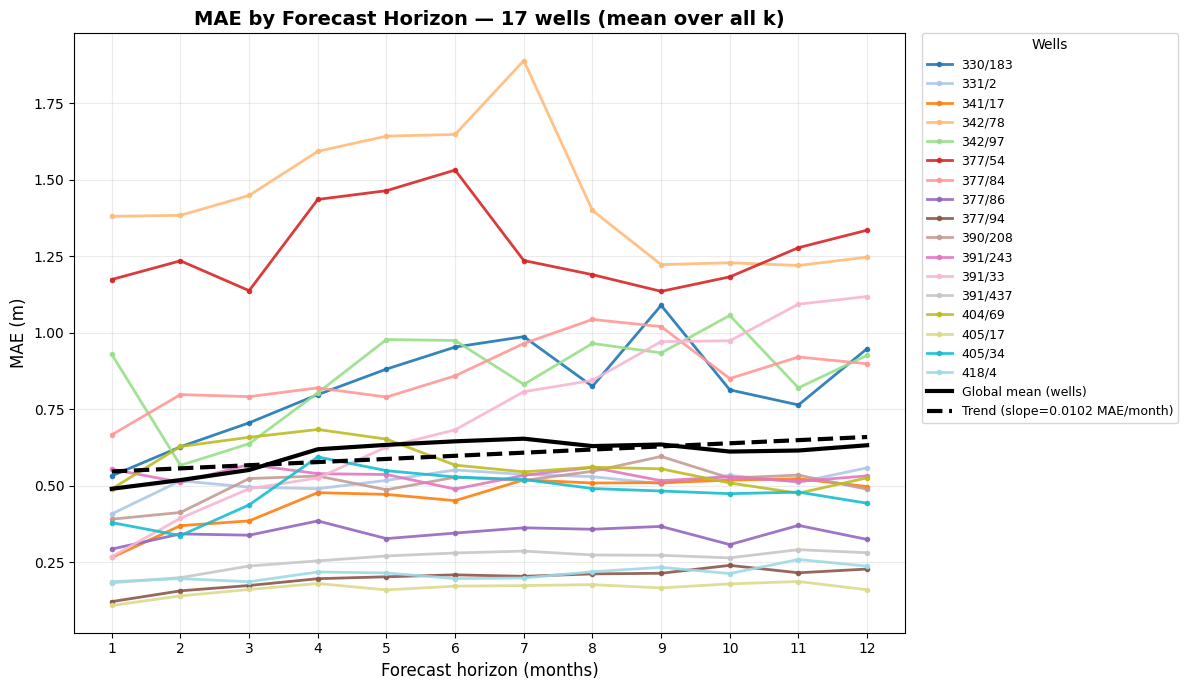

In [24]:
print("\n" + "=" * 80)
print("MAE POR HORIZONTE — 17 POÇOS (MÉDIA SOBRE TODOS OS K) + TENDÊNCIA GLOBAL")
print("=" * 80)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Requer: df_horizon_all_k com colunas ["k","codigo","h","mae"]

# 1) MAE médio por (poço, horizonte) agregando sobre todos os k
df_mean_by_well_h = (
    df_horizon_all_k
    .groupby(["codigo", "h"])["mae"]
    .mean()
    .reset_index()
)

# Pivot: linhas=codigo, colunas=h (1..12)
horizons = list(range(1, 13))
pivot = df_mean_by_well_h.pivot(index="codigo", columns="h", values="mae").reindex(columns=horizons)

# 2) Tendência global (média sobre poços) + regressão linear
global_mean = pivot.mean(axis=0)  # média por horizonte sobre todos os poços
x = np.array(horizons, dtype=float)
y = global_mean.values.astype(float)

mask = ~np.isnan(y)
coef = np.polyfit(x[mask], y[mask], 1)  # y = a*x + b
trend = np.polyval(coef, x)

# 3) Plot with different colors + clean legend
fig, ax = plt.subplots(figsize=(12, 7))

codes = list(pivot.index)
cmap = plt.colormaps["tab20"].resampled(len(codes))  # fixed deprecation warning

for i, codigo in enumerate(codes):
    ax.plot(
        horizons,
        pivot.loc[codigo].values,
        color=cmap(i),
        alpha=0.9,
        linewidth=2,
        marker="o",
        markersize=3,
        label=str(codigo)
    )

# Global mean and trend
ax.plot(horizons, global_mean.values, color="black", linewidth=3, label="Global mean (wells)")
ax.plot(horizons, trend, "k--", linewidth=3,
        label=f"Trend (slope={coef[0]:.4f} MAE/month)")

ax.set_xlabel("Forecast horizon (months)", fontsize=12)
ax.set_ylabel("MAE (m)", fontsize=12)
ax.set_title("MAE by Forecast Horizon — 17 wells (mean over all k)",
             fontsize=14, fontweight="bold")
ax.set_xticks(horizons)
ax.grid(alpha=0.25)

# Clean legend (outside plot)
ax.legend(
    title="Wells",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
    ncol=1,
    fontsize=9
)

plt.tight_layout()

# Export for paper
plt.savefig("resultados_artigo/fig_mae_horizon_17wells.png", dpi=300, bbox_inches="tight")
plt.savefig("resultados_artigo/fig_mae_horizon_17wells.pdf", bbox_inches="tight")
print("\n✓ Exported: resultados_artigo/fig_mae_horizon_17wells.png (300 dpi)")
print("✓ Exported: resultados_artigo/fig_mae_horizon_17wells.pdf")

plt.show()

In [25]:
# Converter resultados para DataFrame
df_rolling_metrics = pd.DataFrame(all_k_results)

print("\n" + "=" * 80)
print("MÉTRICAS AGREGADAS POR POÇO (média e desvio padrão sobre todos os k)")
print("=" * 80)

# Calcular estatísticas agregadas por poço
metrics_summary = df_rolling_metrics.groupby("codigo").agg({
    "rmse": ["mean", "std", "min", "max", "count"],
    "mae": ["mean", "std", "min", "max"],
    "r2": ["mean", "std", "min", "max"],
}).round(4)

# Flatten columns
metrics_summary.columns = ['_'.join(col).strip() for col in metrics_summary.columns.values]
metrics_summary = metrics_summary.reset_index()

# Renomear para clareza
metrics_summary.columns = [
    "codigo", 
    "rmse_mean", "rmse_std", "rmse_min", "rmse_max", "n_evaluations",
    "mae_mean", "mae_std", "mae_min", "mae_max",
    "r2_mean", "r2_std", "r2_min", "r2_max"
]

print(f"\nMétricas agregadas (média ± std sobre {df_rolling_metrics['k'].nunique()} valores de k):\n")
display(metrics_summary)

print("\n" + "=" * 80)
print("MÉTRICAS GLOBAIS (todos os poços)")
print("=" * 80)
print(f"RMSE médio global: {metrics_summary['rmse_mean'].mean():.4f} ± {metrics_summary['rmse_std'].mean():.4f}")
print(f"MAE médio global: {metrics_summary['mae_mean'].mean():.4f} ± {metrics_summary['mae_std'].mean():.4f}")
print(f"R² médio global: {metrics_summary['r2_mean'].mean():.4f} ± {metrics_summary['r2_std'].mean():.4f}")


MÉTRICAS AGREGADAS POR POÇO (média e desvio padrão sobre todos os k)

Métricas agregadas (média ± std sobre 92 valores de k):



,codigo,rmse_mean,rmse_std,rmse_min,rmse_max,n_evaluations,mae_mean,mae_std,mae_min,mae_max,r2_mean,r2_std,r2_min,r2_max
0,330/183,1.1450,0.9145,0.2052,3.3848,92,0.8595,0.6701,0.1687,2.4546,-9.3944,14.8599,-56.4182,0.8993
1,331/2,0.6492,0.1047,0.4207,0.8895,55,0.5137,0.0816,0.2912,0.6570,-0.9598,2.6249,-9.7853,0.6720
2,341/17,0.5157,0.1780,0.1874,0.8540,92,0.4441,0.1676,0.1639,0.8065,0.0113,1.2164,-4.5571,0.9296
3,342/78,1.7732,0.5607,0.6864,4.0160,89,1.4512,0.4516,0.6864,3.1995,-3.4378,11.4647,-66.9867,0.4557
4,342/97,1.1101,0.5696,0.3181,1.9556,56,1.0027,0.5764,0.2943,1.9556,-1.1516,2.3596,-8.5010,0.4189
5,377/54,1.8190,0.5423,0.9415,2.8229,44,1.3052,0.3678,0.7638,2.2129,0.4030,0.4743,-0.9417,0.8925
6,377/84,1.2481,0.1091,1.0819,1.4741,14,0.8683,0.1189,0.6682,1.0367,0.8222,0.0514,0.7512,0.8899
7,377/86,0.4362,0.0887,0.2766,0.6421,92,0.3449,0.0873,0.1856,0.5266,0.8655,0.1209,0.3433,0.9693
8,377/94,0.2406,0.1007,0.1034,0.6031,92,0.2002,0.0857,0.0865,0.4516,-0.5674,1.9425,-14.3520,0.7541
9,390/208,0.6790,0.1380,0.3382,0.9603,44,0.5041,0.1056,0.2684,0.6911,-0.3106,0.5078,-1.3551,0.6953



MÉTRICAS GLOBAIS (todos os poços)
RMSE médio global: 0.7793 ± 0.2878
MAE médio global: 0.6224 ± 0.2490
R² médio global: -3.5010 ± 10.8496


## 11.5.2. ANÁLISE POR K (EFEITO DO TAMANHO DO TREINO)

Avaliar como o erro evolui com k (menos dados de treino), por poço.

In [26]:
print("\n" + "=" * 80)
print("ANÁLISE DE ERRO vs K (POR POÇO)")
print("=" * 80)

# Já temos df_rolling_metrics com métricas por (k, codigo)
# Vamos criar uma visualização interativa por poço

def plot_metrics_vs_k(codigo):
    """Mostra evolução das métricas com k para um poço específico."""
    df_poco = df_rolling_metrics[df_rolling_metrics["codigo"] == codigo].sort_values("k")
    
    if df_poco.empty:
        print(f"⚠️  Sem dados para o poço {codigo}")
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # MAE vs k
    axes[0, 0].plot(df_poco["k"], df_poco["mae"], 'o-', color='blue', linewidth=2)
    axes[0, 0].set_xlabel("k (meses recuados)", fontsize=11)
    axes[0, 0].set_ylabel("MAE (m)", fontsize=11)
    axes[0, 0].set_title(f"Poço {codigo}: MAE vs k", fontsize=12, fontweight="bold")
    axes[0, 0].grid(alpha=0.3)
    
    # RMSE vs k
    axes[0, 1].plot(df_poco["k"], df_poco["rmse"], 'o-', color='red', linewidth=2)
    axes[0, 1].set_xlabel("k (meses recuados)", fontsize=11)
    axes[0, 1].set_ylabel("RMSE (m)", fontsize=11)
    axes[0, 1].set_title(f"Poço {codigo}: RMSE vs k", fontsize=12, fontweight="bold")
    axes[0, 1].grid(alpha=0.3)
    
    # R² vs k
    axes[1, 0].plot(df_poco["k"], df_poco["r2"], 'o-', color='green', linewidth=2)
    axes[1, 0].set_xlabel("k (meses recuados)", fontsize=11)
    axes[1, 0].set_ylabel("R²", fontsize=11)
    axes[1, 0].set_title(f"Poço {codigo}: R² vs k", fontsize=12, fontweight="bold")
    axes[1, 0].grid(alpha=0.3)
    
    # Tamanho do treino vs k
    axes[1, 1].plot(df_poco["k"], df_poco["n_train"], 'o-', color='orange', linewidth=2)
    axes[1, 1].set_xlabel("k (meses recuados)", fontsize=11)
    axes[1, 1].set_ylabel("N obs treino", fontsize=11)
    axes[1, 1].set_title(f"Poço {codigo}: Tamanho Treino vs k", fontsize=12, fontweight="bold")
    axes[1, 1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Mostrar também estatísticas resumidas
    print(f"\nEstatísticas para poço {codigo}:")
    print(f"  MAE médio: {df_poco['mae'].mean():.4f} ± {df_poco['mae'].std():.4f}")
    print(f"  RMSE médio: {df_poco['rmse'].mean():.4f} ± {df_poco['rmse'].std():.4f}")
    print(f"  R² médio: {df_poco['r2'].mean():.4f} ± {df_poco['r2'].std():.4f}")
    print(f"  Valores de k testados: {df_poco['k'].min()} até {df_poco['k'].max()}")

# Widget interativo
available_wells_metrics = sorted(df_rolling_metrics["codigo"].unique())

dropdown_well_metrics = widgets.Dropdown(
    options=available_wells_metrics,
    description="Poço:",
    style={"description_width": "initial"}
)

interactive_metrics = widgets.interactive(plot_metrics_vs_k, codigo=dropdown_well_metrics)
display(interactive_metrics)


ANÁLISE DE ERRO vs K (POR POÇO)


interactive(children=(Dropdown(description='Poço:', options=('330/183', '331/2', '341/17', '342/78', '342/97',…

In [27]:
print("\n" + "=" * 80)
print("EXPORTAÇÃO: MÉTRICAS POR HORIZONTE")
print("=" * 80)

# Exportar tabela detalhada (formato longo: k, codigo, h, mae)
if not df_horizon_all_k.empty:
    df_horizon_all_k.to_csv("exports_csv/mae_by_horizon_detailed.csv", index=False)
    print("✓ Exportado: mae_by_horizon_detailed.csv (formato longo: k, codigo, h, mae)")

print("\n" + "=" * 80)
print("ANÁLISE POR HORIZONTE: CONCLUÍDA")
print("=" * 80)


EXPORTAÇÃO: MÉTRICAS POR HORIZONTE
✓ Exportado: mae_by_horizon_detailed.csv (formato longo: k, codigo, h, mae)

ANÁLISE POR HORIZONTE: CONCLUÍDA


In [28]:
print("\n" + "=" * 80)
print("INTERACTIVE VISUALIZATION: VALIDATION BY WELL AND K (RECURSIVO)")
print("=" * 80)

# Prepare complete data for visualization
hist_df_full = df_model_base.copy().sort_values(["codigo", "ym"])

def plot_by_well_and_k(codigo, k_value):
    """Plots history + test period with RECURSIVE predictions for a specific k."""
    if k_value not in all_k_predictions:
        print(f"⚠️ No data for k={k_value}")
        return
    
    k_data = all_k_predictions[k_value]
    df_train_full_k = k_data["df_train_full"]
    df_test_full_k = k_data["df_test_full"]
    df_test_eval_k = k_data["df_test_eval"]
    predictions_k = k_data.get("predictions", {})
    
    # Complete history of the well
    g_hist = hist_df_full[hist_df_full["codigo"] == codigo].sort_values("ym")
    g_test = df_test_full_k[df_test_full_k["codigo"] == codigo].sort_values("ym")
    g_test_eval = df_test_eval_k[df_test_eval_k["codigo"] == codigo].sort_values("ym")
    
    # Get recursive predictions (already calculated)
    g_preds = predictions_k.get(codigo, pd.DataFrame())
    
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Complete history (APENAS VALORES REAIS, com quebras em gaps)
    g_hist_real = g_hist[g_hist["prof_original"].notna()].copy().sort_values("ym")
    
    if not g_hist_real.empty:
        # Identificar quebras (gaps > 1 mês)
        g_hist_real["gap"] = (g_hist_real["ym"].diff().dt.days > 35)  # >1 mês
        break_indices = g_hist_real[g_hist_real["gap"]].index
        
        # Plotar segmentos contínuos
        start_idx = 0
        for break_idx in list(break_indices) + [None]:
            if break_idx is None:
                segment = g_hist_real.iloc[start_idx:]
            else:
                segment = g_hist_real.iloc[start_idx:g_hist_real.index.get_loc(break_idx)]
                start_idx = g_hist_real.index.get_loc(break_idx)
            
            if not segment.empty:
                ax.plot(segment["ym"], segment["profundidade"],
                       "o-", color="steelblue", markersize=4, alpha=0.7)
        
        # Legenda apenas uma vez
        ax.plot([], [], "o-", label="History (real)", color="steelblue", markersize=4, alpha=0.7)
    
    # Test period (real values)
    g_test_real = g_test[g_test["prof_original"].notna()]
    if not g_test_real.empty:
        ax.plot(g_test_real["ym"], g_test_real["profundidade"],
                "o", label="Test (real)", color="green", markersize=6, alpha=0.8)
    
    # Recursive Predictions
    if not g_preds.empty:
        ax.plot(g_preds["ym"], g_preds["pred"],
                "x-", label="Predictions (recursive)", color="red", markersize=7, linewidth=2)
    
    # Vertical line at cutoff (end of training for this k)
    if not g_test.empty:
        cutoff = g_test["ym"].min()
        ax.axvline(cutoff, color="orange", linestyle="--", linewidth=1.5,
                   label=f"Test start: {cutoff.strftime('%Y-%m')}")
    
    ax.set_xlabel("Date", fontsize=11)
    ax.set_ylabel("Depth (m)", fontsize=11)
    ax.set_title(f"Well {codigo} (k={k_value}): Validation with {k_value} months rolled back",
                 fontsize=13, fontweight="bold")
    ax.invert_yaxis()  # Invert Y axis (perspective from below ground)
    ax.legend(loc="best", fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Interactive widgets
k_values = sorted(all_k_predictions.keys())
available_wells = sorted(df_rolling_metrics["codigo"].unique())

dropdown_well = widgets.Dropdown(
    options=available_wells,
    description="Well:",
    style={"description_width": "initial"}
)

dropdown_k = widgets.Dropdown(
    options=k_values,
    description="k (months rolled back):",
    style={"description_width": "initial"}
)

interactive_plot = widgets.interactive(plot_by_well_and_k, codigo=dropdown_well, k_value=dropdown_k)
display(interactive_plot)


INTERACTIVE VISUALIZATION: VALIDATION BY WELL AND K (RECURSIVO)


interactive(children=(Dropdown(description='Well:', options=('330/183', '331/2', '341/17', '342/78', '342/97',…

k válidos por poço (com >= MIN_TRAIN_OBS_PER_WELL observações de treino):
  330/183: k=0..91  (92 valores de k)
  331/2: k=0..54  (55 valores de k)
  341/17: k=0..91  (92 valores de k)
  342/78: k=0..91  (92 valores de k)
  342/97: k=0..58  (59 valores de k)
  377/54: k=0..43  (44 valores de k)
  377/84: k=0..13  (14 valores de k)
  377/86: k=0..91  (92 valores de k)
  377/94: k=0..91  (92 valores de k)
  390/208: k=0..43  (44 valores de k)
  391/243: k=0..91  (92 valores de k)
  391/33: k=0..91  (92 valores de k)
  391/437: k=0..91  (92 valores de k)
  404/69: k=0..91  (92 valores de k)
  405/17: k=0..91  (92 valores de k)
  405/34: k=0..88  (89 valores de k)
  418/4: k=0..91  (92 valores de k)


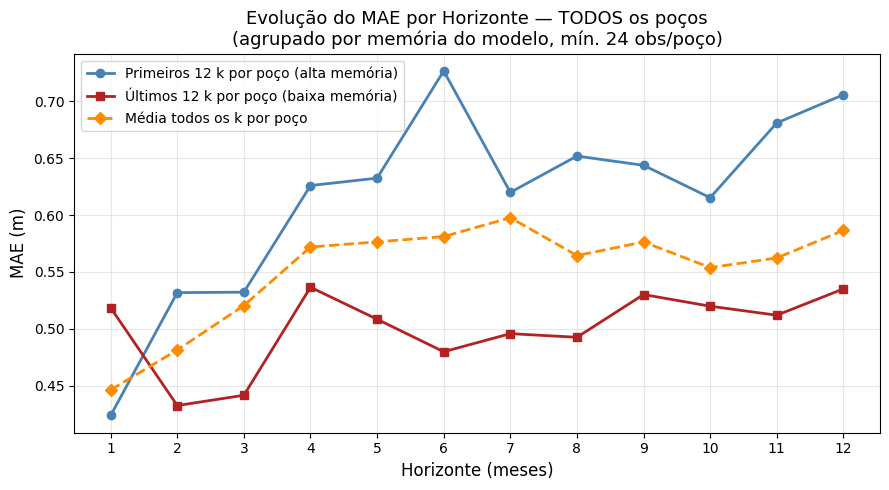

In [29]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ─── Identificar os k válidos por poço ───────────────────────────────────────
# Um k é "válido" para um poço se ele aparece em df_train_eval com >= MIN_TRAIN_OBS_PER_WELL obs
well_valid_ks = {}
for k in sorted(all_k_predictions.keys()):
    df_train_k = all_k_predictions[k]["df_train_eval"]
    for cod, g in df_train_k.groupby("codigo"):
        if len(g) >= MIN_TRAIN_OBS_PER_WELL:
            well_valid_ks.setdefault(cod, []).append(k)

# Resumo dos k válidos por poço
print("k válidos por poço (com >= MIN_TRAIN_OBS_PER_WELL observações de treino):")
for cod, ks in sorted(well_valid_ks.items()):
    print(f"  {cod}: k=0..{max(ks)}  ({len(ks)} valores de k)")

# ─── Função: MAE médio por horizonte com grupos de k por poço ────────────────
def mean_mae_by_horizon_perwell(all_k_predictions, well_valid_ks, group="small"):
    """
    Calcula MAE médio por horizonte H1-H12 usando grupos de k por poço.
    
    group="small" → primeiros 12 k válidos de cada poço (alta memória)
    group="large" → últimos 12 k válidos de cada poço (baixa memória)
    group="all"   → todos os k válidos de cada poço
    
    Para cada poço, apenas os k onde tem >= MIN_TRAIN_OBS_PER_WELL obs de treino.
    Usa apenas observações reais (prof_original não NaN) no teste.
    """
    records = []
    for cod, valid_ks in well_valid_ks.items():
        valid_ks_sorted = sorted(valid_ks)

        if group == "small":
            k_list = valid_ks_sorted[:12]
        elif group == "large":
            k_list = valid_ks_sorted[-12:]
        else:
            k_list = valid_ks_sorted

        for k in k_list:
            k_data = all_k_predictions[k]
            predictions_k  = k_data["predictions"]
            df_test_eval_k = k_data["df_test_eval"]

            if cod not in predictions_k:
                continue

            df_preds = predictions_k[cod]
            df_test  = df_test_eval_k[
                (df_test_eval_k["codigo"] == cod) &
                (df_test_eval_k["prof_original"].notna())
            ][["ym", "profundidade"]].copy()

            df_merged = df_test.merge(df_preds, on="ym", how="inner").sort_values("ym")
            if df_merged.empty:
                continue

            test_start = df_merged["ym"].min()
            df_merged["h"] = (
                (df_merged["ym"].dt.year  - test_start.year)  * 12 +
                (df_merged["ym"].dt.month - test_start.month) + 1
            )
            df_merged["abs_error"] = np.abs(df_merged["profundidade"] - df_merged["pred"])

            for h in range(1, 13):
                h_data = df_merged[df_merged["h"] == h]
                if not h_data.empty:
                    records.append({"h": h, "mae": h_data["abs_error"].mean()})

    df = pd.DataFrame(records)
    return df.groupby("h")["mae"].mean() if not df.empty else pd.Series(dtype=float)

# ─── Calcular as 3 séries (por poço) ─────────────────────────────────────────
mae_small = mean_mae_by_horizon_perwell(all_k_predictions, well_valid_ks, group="small")
mae_large = mean_mae_by_horizon_perwell(all_k_predictions, well_valid_ks, group="large")
mae_all   = mean_mae_by_horizon_perwell(all_k_predictions, well_valid_ks, group="all")

# ─── Plot ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(mae_small.index, mae_small.values,
        marker="o", color="steelblue", linewidth=2,
        label="Primeiros 12 k por poço (alta memória)")

ax.plot(mae_large.index, mae_large.values,
        marker="s", color="firebrick", linewidth=2,
        label="Últimos 12 k por poço (baixa memória)")

ax.plot(mae_all.index, mae_all.values,
        marker="D", color="darkorange", linewidth=2,
        linestyle="--",
        label="Média todos os k por poço")

ax.set_xlabel("Horizonte (meses)", fontsize=12)
ax.set_ylabel("MAE (m)", fontsize=12)
ax.set_title("Evolução do MAE por Horizonte — TODOS os poços\n"
             f"(agrupado por memória do modelo, mín. {MIN_TRAIN_OBS_PER_WELL} obs/poço)", fontsize=13)
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("fig5_new_memory_perwell.png", dpi=150)
plt.show()


VISUALIZAÇÃO: EVOLUÇÃO DAS MÉTRICAS POR K


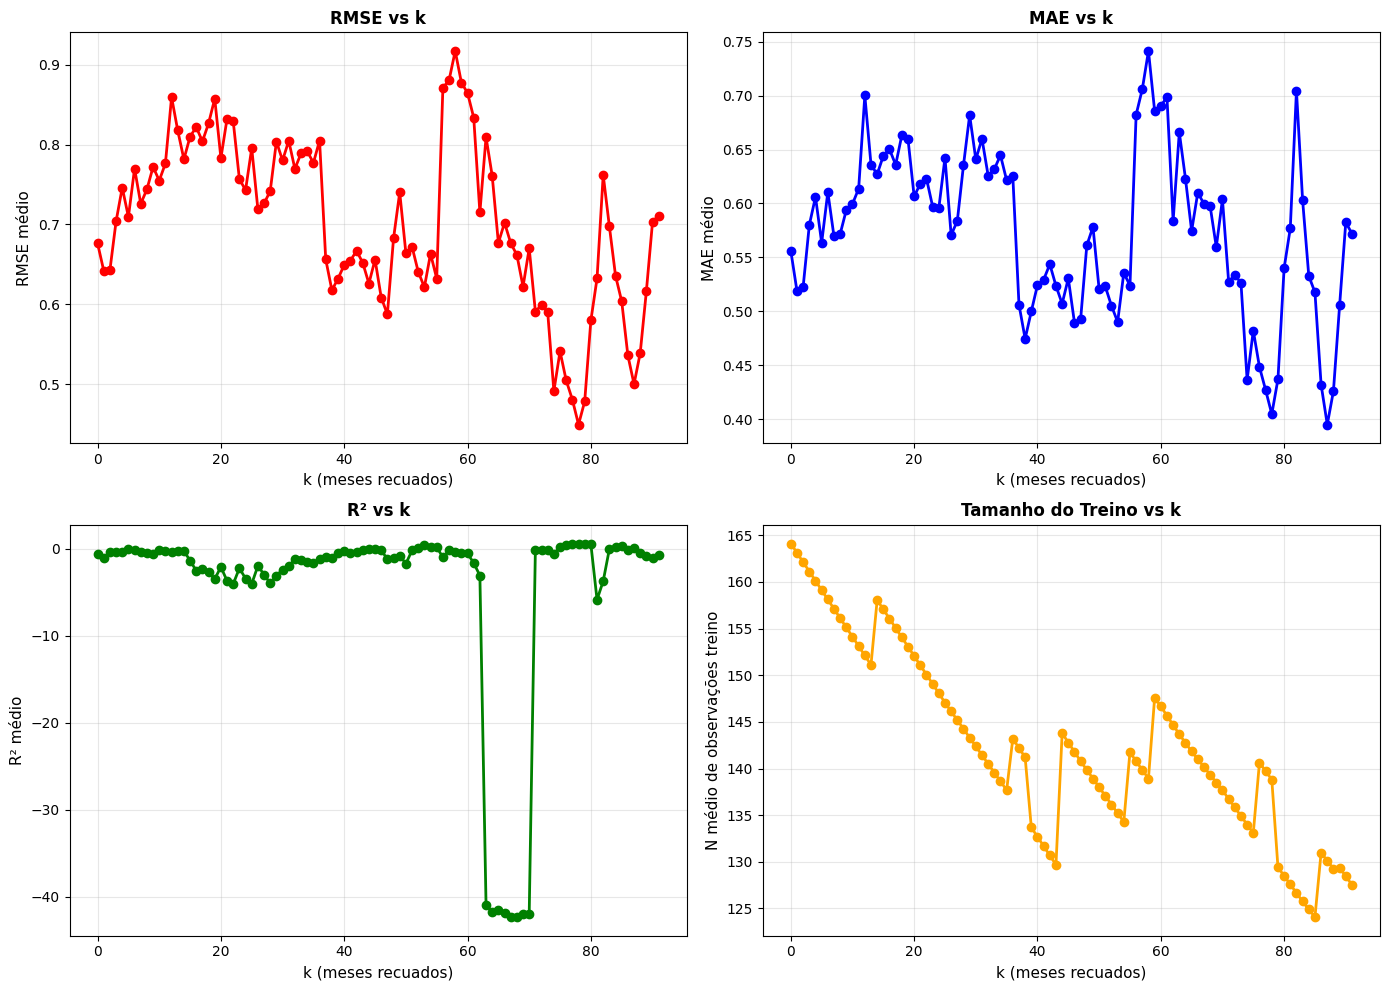


✓ Gráficos de evolução das métricas por k gerados


In [30]:
print("\n" + "=" * 80)
print("VISUALIZAÇÃO: EVOLUÇÃO DAS MÉTRICAS POR K")
print("=" * 80)

# Agregar métricas por k
metrics_by_k = df_rolling_metrics.groupby("k").agg({
    "rmse": "mean",
    "mae": "mean",
    "r2": "mean",
    "n_train": "mean",
}).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# RMSE por k
axes[0, 0].plot(metrics_by_k["k"], metrics_by_k["rmse"], 'o-', color='red', linewidth=2)
axes[0, 0].set_xlabel("k (meses recuados)", fontsize=11)
axes[0, 0].set_ylabel("RMSE médio", fontsize=11)
axes[0, 0].set_title("RMSE vs k", fontsize=12, fontweight="bold")
axes[0, 0].grid(alpha=0.3)

# MAE por k
axes[0, 1].plot(metrics_by_k["k"], metrics_by_k["mae"], 'o-', color='blue', linewidth=2)
axes[0, 1].set_xlabel("k (meses recuados)", fontsize=11)
axes[0, 1].set_ylabel("MAE médio", fontsize=11)
axes[0, 1].set_title("MAE vs k", fontsize=12, fontweight="bold")
axes[0, 1].grid(alpha=0.3)

# R² por k
axes[1, 0].plot(metrics_by_k["k"], metrics_by_k["r2"], 'o-', color='green', linewidth=2)
axes[1, 0].set_xlabel("k (meses recuados)", fontsize=11)
axes[1, 0].set_ylabel("R² médio", fontsize=11)
axes[1, 0].set_title("R² vs k", fontsize=12, fontweight="bold")
axes[1, 0].grid(alpha=0.3)

# Tamanho do treino por k
axes[1, 1].plot(metrics_by_k["k"], metrics_by_k["n_train"], 'o-', color='orange', linewidth=2)
axes[1, 1].set_xlabel("k (meses recuados)", fontsize=11)
axes[1, 1].set_ylabel("N médio de observações treino", fontsize=11)
axes[1, 1].set_title("Tamanho do Treino vs k", fontsize=12, fontweight="bold")
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Gráficos de evolução das métricas por k gerados")

In [31]:
print("\n" + "=" * 80)
print("EXPORTAÇÃO: RESULTADOS ROLLING-ORIGIN")
print("=" * 80)

# Exportar métricas detalhadas (todos os k)
df_rolling_metrics.to_csv("exports_csv/rolling_origin_all_k.csv", index=False)
print("✓ Exportado: rolling_origin_all_k.csv (métricas para cada k e poço)")

# Exportar métricas agregadas (média/std por poço)
metrics_summary.to_csv("exports_csv/rolling_origin_summary.csv", index=False)
print("✓ Exportado: rolling_origin_summary.csv (estatísticas agregadas por poço)")

# Exportar métricas agregadas por k
metrics_by_k.to_csv("exports_csv/rolling_origin_by_k.csv", index=False)
print("✓ Exportado: rolling_origin_by_k.csv (métricas agregadas por k)")

print("\n" + "=" * 80)
print("ROLLING-ORIGIN VALIDATION: CONCLUÍDA")
print("=" * 80)


EXPORTAÇÃO: RESULTADOS ROLLING-ORIGIN
✓ Exportado: rolling_origin_all_k.csv (métricas para cada k e poço)
✓ Exportado: rolling_origin_summary.csv (estatísticas agregadas por poço)
✓ Exportado: rolling_origin_by_k.csv (métricas agregadas por k)

ROLLING-ORIGIN VALIDATION: CONCLUÍDA


## 11.6. FORECAST FUTURO: 12 MESES À FRENTE

Agora fazemos o "trabalho inverso": em vez de recuar no tempo (k positivo), avançamos para o futuro.
- Treina com TODOS os dados disponíveis de cada poço
- Gera previsões recursivas para os próximos 12 meses
- Usa climatologia para as variáveis exógenas (rr, eto, caudal)

In [32]:
print("\n" + "=" * 80)
print("FORECAST FUTURO: 12 MESES À FRENTE")
print("=" * 80)

# Calcular climatologia com TODOS os dados (sem offset)
climatology_full = calculate_climatology(df_model_base, max_date=None)

# Treinar modelos com todos os dados disponíveis
print("\n✓ Treino de modelos com todos os dados disponíveis...")
models_future = {}
scalers_future = {}
predictions_future = {}

for cod, g in df_trainable.groupby("codigo"):
    if g.empty:
        continue
    
    X = g[feature_cols].copy()
    y = g["profundidade"].copy()
    
    # Scaler
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Modelo XGBoost
    model = XGBRegressor(
        n_estimators=600,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
    )
    model.fit(X_scaled, y, verbose=False)
    
    models_future[cod] = model
    scalers_future[cod] = scaler
    
    # Forecast recursivo de 12 meses
    df_hist_poco = df_model_base[df_model_base["codigo"] == cod].copy()
    last_valid_date = g["ym"].max()
    
    df_preds_future = recursive_forecast_12m(
        model, 
        scaler, 
        df_hist_poco, 
        feature_cols, 
        last_valid_date, 
        climatology_full
    )
    
    predictions_future[cod] = df_preds_future

print(f"✓ Modelos treinados: {len(models_future)}")
print(f"✓ Forecast futuro calculado para {len(predictions_future)} poços")

# Consolidar previsões futuras em DataFrame
future_rows = []
for cod, df_pred in predictions_future.items():
    df_pred_copy = df_pred.copy()
    df_pred_copy["codigo"] = cod
    future_rows.append(df_pred_copy)

df_preds_future_all = pd.concat(future_rows, ignore_index=True) if future_rows else pd.DataFrame()

print(f"\n✓ Total de previsões futuras: {len(df_preds_future_all)} (12 meses × {len(predictions_future)} poços)")
print(f"✓ Período das previsões: {df_preds_future_all['ym'].min()} até {df_preds_future_all['ym'].max()}")

# Exibir amostra
print("\n" + "─" * 80)
print("AMOSTRA DAS PREVISÕES FUTURAS")
print("─" * 80)
df_preds_future_all.head(24)


FORECAST FUTURO: 12 MESES À FRENTE

✓ Treino de modelos com todos os dados disponíveis...
✓ Modelos treinados: 17
✓ Forecast futuro calculado para 17 poços

✓ Total de previsões futuras: 204 (12 meses × 17 poços)
✓ Período das previsões: 2008-04-01 00:00:00 até 2026-01-01 00:00:00

────────────────────────────────────────────────────────────────────────────────
AMOSTRA DAS PREVISÕES FUTURAS
────────────────────────────────────────────────────────────────────────────────


,ym,pred,codigo
0,2025-02-01,1.366836,330/183
1,2025-03-01,1.362280,330/183
2,2025-04-01,1.431941,330/183
3,2025-05-01,1.532085,330/183
4,2025-06-01,1.737560,330/183
5,2025-07-01,2.024484,330/183
6,2025-08-01,2.498544,330/183
7,2025-09-01,2.667810,330/183
8,2025-10-01,1.747897,330/183
9,2025-11-01,1.465860,330/183


In [33]:
print("\n" + "=" * 80)
print("VISUALIZAÇÃO: FORECAST FUTURO POR POÇO")
print("=" * 80)

def plot_future_forecast(codigo):
    """Plots histórico completo + forecast futuro de 12 meses."""
    if codigo not in predictions_future:
        print(f"⚠️ Sem previsões para o poço {codigo}")
        return
    
    # Histórico completo
    g_hist = hist_df_full[hist_df_full["codigo"] == codigo].sort_values("ym")
    
    # Previsões futuras
    g_preds = predictions_future[codigo]
    
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Histórico (APENAS VALORES REAIS, com quebras em gaps)
    g_hist_real = g_hist[g_hist["prof_original"].notna()].copy().sort_values("ym")
    
    if not g_hist_real.empty:
        # Identificar quebras (gaps > 1 mês)
        g_hist_real["gap"] = (g_hist_real["ym"].diff().dt.days > 35)  # >1 mês
        break_indices = g_hist_real[g_hist_real["gap"]].index
        
        # Plotar segmentos contínuos
        start_idx = 0
        for break_idx in list(break_indices) + [None]:
            if break_idx is None:
                segment = g_hist_real.iloc[start_idx:]
            else:
                segment = g_hist_real.iloc[start_idx:g_hist_real.index.get_loc(break_idx)]
                start_idx = g_hist_real.index.get_loc(break_idx)
            
            if not segment.empty:
                ax.plot(segment["ym"], segment["profundidade"],
                       "o-", color="steelblue", markersize=4, alpha=0.7)
        
        # Legenda apenas uma vez
        ax.plot([], [], "o-", label="History (real)", color="steelblue", markersize=4, alpha=0.7)
    
    # Forecast futuro
    if not g_preds.empty:
        ax.plot(g_preds["ym"], g_preds["pred"],
                "x-", label="Future forecast (12 months)", color="red", markersize=7, linewidth=2.5)
        
        # Linha vertical no início do forecast
        forecast_start = g_preds["ym"].min()
        ax.axvline(forecast_start, color="orange", linestyle="--", linewidth=1.5,
                   label=f"Forecast start: {forecast_start.strftime('%Y-%m')}")
    
    ax.set_xlabel("Date", fontsize=11)
    ax.set_ylabel("Depth (m)", fontsize=11)
    ax.set_title(f"Well {codigo}: Complete History + 12-Month Future Forecast",
                 fontsize=13, fontweight="bold")
    ax.invert_yaxis()
    ax.legend(loc="best", fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Widget interativo
available_wells_future = sorted(predictions_future.keys())

dropdown_well_future = widgets.Dropdown(
    options=available_wells_future,
    description="Well:",
    style={"description_width": "initial"}
)

interactive_future = widgets.interactive(plot_future_forecast, codigo=dropdown_well_future)
display(interactive_future)


VISUALIZAÇÃO: FORECAST FUTURO POR POÇO


interactive(children=(Dropdown(description='Well:', options=('330/183', '331/2', '341/17', '342/78', '342/97',…

In [34]:
print("\n" + "=" * 80)
print("EXPORTAÇÃO: PREVISÕES FUTURAS")
print("=" * 80)

# Exportar previsões futuras
df_preds_future_all.to_csv("exports_csv/preds_future_12m_recursive.csv", index=False)
print("✓ Exportado: exports_csv/preds_future_12m_recursive.csv")

# Exportar modelos e scalers (pickle)
import pickle

with open("model_future.pkl", "wb") as f:
    pickle.dump(models_future, f)
print("✓ Exportado: model_future.pkl")

with open("scaler_future.pkl", "wb") as f:
    pickle.dump(scalers_future, f)
print("✓ Exportado: scaler_future.pkl")

print("\n" + "=" * 80)
print("FORECAST FUTURO: CONCLUÍDO")
print("=" * 80)


EXPORTAÇÃO: PREVISÕES FUTURAS
✓ Exportado: exports_csv/preds_future_12m_recursive.csv
✓ Exportado: model_future.pkl
✓ Exportado: scaler_future.pkl

FORECAST FUTURO: CONCLUÍDO


## 11.7. FEATURE IMPORTANCE (MODELOS FUTUROS)

Análise da importância relativa de cada variável nos modelos treinados por poço.

In [35]:
def get_feature_importance_gain(model, feature_cols):
    """
    Extrai feature importance (gain) de um modelo XGBoost.
    
    Parâmetros:
    - model: XGBRegressor treinado
    - feature_cols: lista de nomes das features
    
    Retorna:
    - DataFrame com colunas ['feature', 'gain', 'gain_pct']
    """
    booster = model.get_booster()
    scores = booster.get_score(importance_type="gain")  # dict: {"f0":..., "f1":...}
    
    # Converter f0..fN para nomes reais
    out = []
    for i, name in enumerate(feature_cols):
        out.append((name, scores.get(f"f{i}", 0.0)))
    
    df_imp = pd.DataFrame(out, columns=["feature", "gain"]).sort_values("gain", ascending=False)
    
    # Percentagem
    total_gain = df_imp["gain"].sum()
    df_imp["gain_pct"] = (df_imp["gain"] / total_gain * 100) if total_gain > 0 else 0
    
    return df_imp

print("✓ Função get_feature_importance_gain() definida")

✓ Função get_feature_importance_gain() definida


In [36]:
print("\n" + "=" * 80)
print("FEATURE IMPORTANCE POR POÇO")
print("=" * 80)

def plot_feature_importance(codigo):
    """Mostra feature importance para um poço específico."""
    if codigo not in models_future:
        print(f"⚠️  Modelo não encontrado para o poço {codigo}")
        return
    
    model = models_future[codigo]
    df_imp = get_feature_importance_gain(model, feature_cols)
    
    # Gráfico
    fig, ax = plt.subplots(figsize=(10, 6))
    
    colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(df_imp)))
    bars = ax.barh(df_imp["feature"], df_imp["gain_pct"], color=colors)
    
    ax.set_xlabel("Importância relativa (%)", fontsize=11)
    ax.set_title(f"Feature Importance (Gain) - Poço {codigo}", fontsize=13, fontweight="bold")
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)
    
    # Adicionar percentagens nas barras
    for i, (feat, val) in enumerate(zip(df_imp["feature"], df_imp["gain_pct"])):
        ax.text(val + 0.5, i, f"{val:.1f}%", va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    # Mostrar tabela
    print(f"\nImportância das features (Poço {codigo}):")
    display(df_imp.style.format({"gain": "{:.2f}", "gain_pct": "{:.1f}%"}))

# Widget interativo
available_wells_imp = sorted(models_future.keys())

dropdown_well_imp = widgets.Dropdown(
    options=available_wells_imp,
    description="Poço:",
    style={"description_width": "initial"}
)

interactive_imp = widgets.interactive(plot_feature_importance, codigo=dropdown_well_imp)
display(interactive_imp)


FEATURE IMPORTANCE POR POÇO


interactive(children=(Dropdown(description='Poço:', options=('330/183', '331/2', '341/17', '342/78', '342/97',…

In [37]:
print("\n" + "=" * 80)
print("COMPARAÇÃO DE FEATURE IMPORTANCE ENTRE POÇOS")
print("=" * 80)

# Extrair importance de todos os poços
rows_imp = []
for cod, model in models_future.items():
    df_imp = get_feature_importance_gain(model, feature_cols)
    df_imp["codigo"] = cod
    rows_imp.append(df_imp)

df_imp_all = pd.concat(rows_imp, ignore_index=True)

# Pivot: linhas=features, colunas=poços, valores=gain_pct
df_pivot_imp = df_imp_all.pivot_table(
    index="feature", 
    columns="codigo", 
    values="gain_pct", 
    aggfunc="sum"
).fillna(0)

# Adicionar média entre poços
df_pivot_imp["Média"] = df_pivot_imp.mean(axis=1)
df_pivot_imp = df_pivot_imp.sort_values("Média", ascending=False)

print(f"\n✓ Feature importance calculada para {len(models_future)} poços")
print("\nImportância média por feature (% gain):\n")
display(df_pivot_imp.style.format("{:.1f}").background_gradient(cmap="YlOrRd", axis=None))

# Exportar
df_pivot_imp.to_csv("exports_csv/feature_importance_by_well.csv")
print("\n✓ Exportado: exports_csv/feature_importance_by_well.csv")


COMPARAÇÃO DE FEATURE IMPORTANCE ENTRE POÇOS

✓ Feature importance calculada para 17 poços

Importância média por feature (% gain):



codigo,330/183,331/2,341/17,342/78,342/97,377/54,377/84,377/86,377/94,390/208,391/243,391/33,391/437,404/69,405/17,405/34,418/4,Média
feature,,,,,,,,,,,,,,,,,,
profundidade_lag1,53.1,29.9,43.8,36.5,45.8,8.1,9.5,14.3,68.1,31.0,55.6,65.7,52.4,43.7,41.9,56.7,54.1,41.8
eto_lag1,5.4,5.1,5.4,5.9,2.3,56.1,61.1,40.3,1.4,8.8,2.6,1.9,13.2,4.9,13.5,2.0,3.9,13.7
profundidade_lag2,14.8,4.0,7.6,12.2,16.8,5.1,1.2,3.5,19.3,7.9,15.5,15.3,5.0,6.7,7.2,8.0,8.1,9.3
mes_cos,15.2,3.5,4.8,12.7,6.6,9.0,8.3,26.5,0.9,2.1,6.9,1.5,12.9,9.0,28.0,1.2,2.8,8.9
eto_lag2,2.2,7.4,8.6,4.3,4.5,6.0,8.0,2.8,0.8,16.1,1.8,1.3,9.0,12.8,2.1,1.6,15.7,6.2
caudal_lag1,1.8,28.5,12.7,9.1,4.3,5.6,0.5,1.4,2.2,4.4,5.5,4.3,2.4,1.5,1.6,12.9,2.5,6.0
mes_sin,1.3,4.4,7.4,6.2,1.0,3.6,5.6,8.0,1.4,17.9,3.1,2.5,1.1,10.5,1.3,2.7,1.9,4.7
rr_lag1,2.7,6.2,1.9,3.7,12.1,1.2,0.3,1.4,1.9,4.3,5.2,3.5,1.2,5.5,1.5,6.5,5.6,3.8
caudal_lag2,1.9,7.4,5.4,4.8,4.0,2.3,1.6,1.0,1.1,5.3,2.2,0.9,1.7,2.2,1.5,5.6,1.8,3.0



✓ Exportado: exports_csv/feature_importance_by_well.csv



VIOLIN PLOT: DISTRIBUIÇÃO DA FEATURE IMPORTANCE (17 POÇOS)

✓ Exported: resultados_artigo/fig_violin_feature_importance.png (300 dpi)
✓ Exported: resultados_artigo/fig_violin_feature_importance.pdf


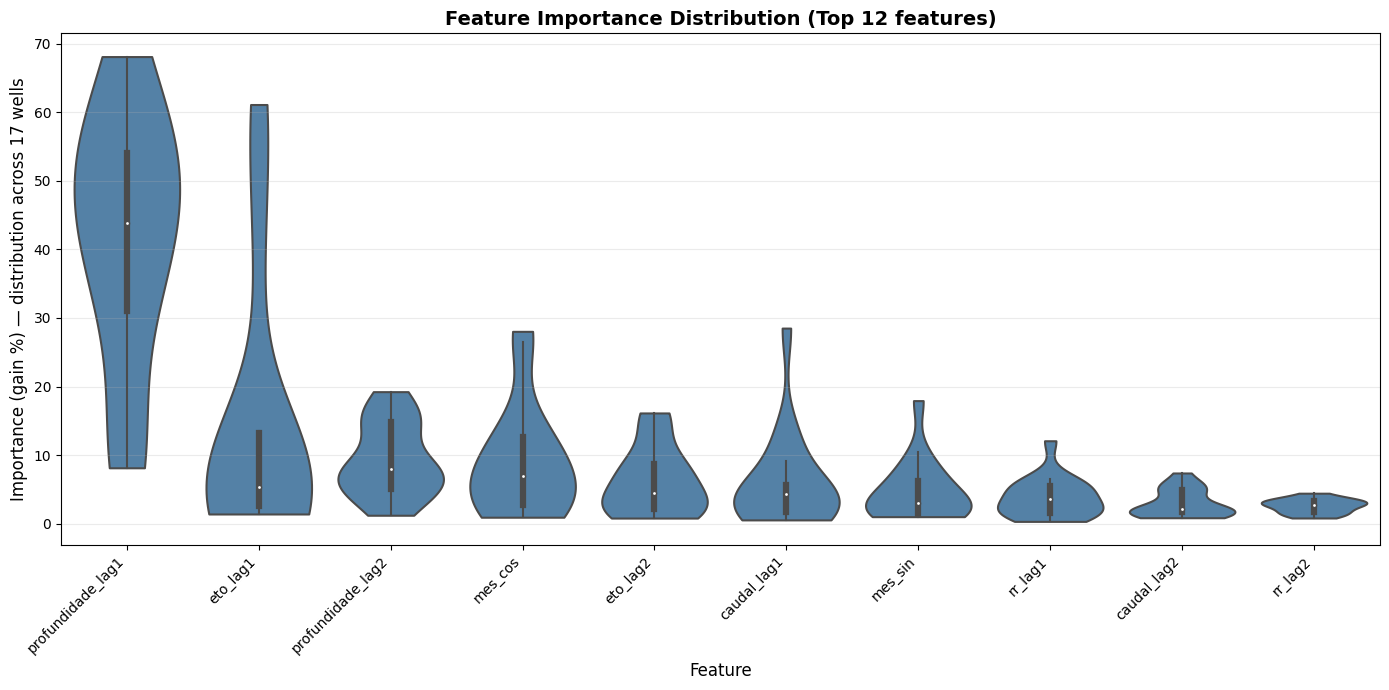


📊 Interpretation:
  - Wide violins = feature importance varies significantly across wells
  - Narrow violins = feature importance is consistent across wells
  - Inner box = median and quartiles (Q1, Q3)


In [38]:
print("\n" + "=" * 80)
print("VIOLIN PLOT: DISTRIBUIÇÃO DA FEATURE IMPORTANCE (17 POÇOS)")
print("=" * 80)

import seaborn as sns

# df_imp_all já existe no notebook (feature, gain, gain_pct, codigo)
# Vamos usar gain_pct (normalizado por poço)

# Selecionar top N features pela média de gain_pct
top_n = 12
top_features = (
    df_imp_all.groupby("feature")["gain_pct"].mean()
    .sort_values(ascending=False)
    .head(top_n)
    .index
)

df_plot = df_imp_all[df_imp_all["feature"].isin(top_features)].copy()

# Reordenar features pela média (para ficar mais visual)
feature_order = (
    df_plot.groupby("feature")["gain_pct"].mean()
    .sort_values(ascending=False)
    .index
)

# Plot
fig, ax = plt.subplots(figsize=(14, 7))
sns.violinplot(
    data=df_plot,
    x="feature",
    y="gain_pct",
    order=feature_order,
    inner="box",      # mostra mediana/quartis
    cut=0,            # não extrapola além dos dados
    scale="width",    # largura comparável
    color="steelblue",
    alpha=0.7
)

ax.set_xlabel("Feature", fontsize=12)
ax.set_ylabel("Importance (gain %) — distribution across 17 wells", fontsize=12)
ax.set_title(f"Feature Importance Distribution (Top {top_n} features)",
             fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()

# Export for paper
plt.savefig("resultados_artigo/fig_violin_feature_importance.png", dpi=300, bbox_inches="tight")
plt.savefig("resultados_artigo/fig_violin_feature_importance.pdf", bbox_inches="tight")
print("\n✓ Exported: resultados_artigo/fig_violin_feature_importance.png (300 dpi)")
print("✓ Exported: resultados_artigo/fig_violin_feature_importance.pdf")

plt.show()

print("\n📊 Interpretation:")
print("  - Wide violins = feature importance varies significantly across wells")
print("  - Narrow violins = feature importance is consistent across wells")
print("  - Inner box = median and quartiles (Q1, Q3)")


FEATURE IMPORTANCE AGREGADA POR GRUPO

Importância por grupo de variáveis (% gain médio):



codigo,330/183,331/2,341/17,342/78,342/97,377/54,377/84,377/86,377/94,390/208,391/243,391/33,391/437,404/69,405/17,405/34,418/4,Média
categoria,,,,,,,,,,,,,,,,,,
Lags do alvo,67.8,33.9,51.4,48.8,62.6,13.2,10.7,17.8,87.4,38.9,71.0,81.0,57.4,50.4,49.1,64.7,62.2,51.1
Evapotranspiração (eto),7.6,12.5,14.0,10.2,6.8,62.1,69.1,43.1,2.2,24.9,4.4,3.2,22.2,17.7,15.6,3.6,19.6,19.9
Sazonalidade,16.5,7.9,12.3,18.9,7.6,12.6,14.0,34.5,2.3,20.1,10.0,4.0,13.9,19.4,29.4,3.8,4.6,13.6
Caudal,3.7,35.9,18.1,14.0,8.3,7.8,2.2,2.4,3.3,9.7,7.7,5.2,4.2,3.7,3.1,18.6,4.3,8.9
Chuva (rr),4.3,9.7,4.2,8.1,14.7,4.2,4.0,2.2,4.8,6.4,6.8,6.5,2.3,8.8,2.9,9.3,9.3,6.4


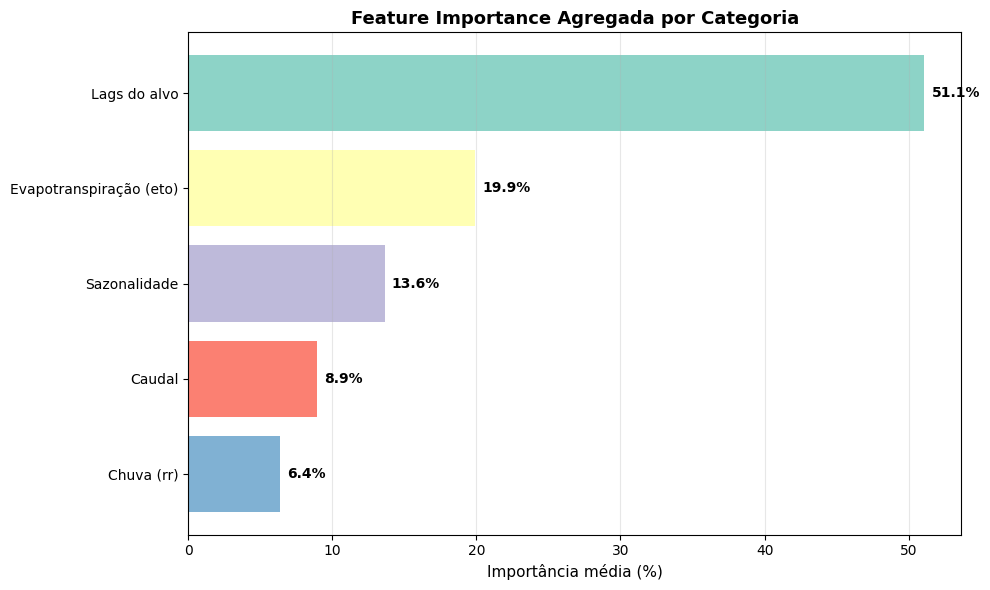


ANÁLISE DE FEATURE IMPORTANCE: CONCLUÍDA


In [39]:
print("\n" + "=" * 80)
print("FEATURE IMPORTANCE AGREGADA POR GRUPO")
print("=" * 80)

# Agrupar features por categoria
def categorize_feature(feat):
    if "profundidade_lag" in feat:
        return "Lags do alvo"
    elif "rr_lag" in feat:
        return "Chuva (rr)"
    elif "eto_lag" in feat:
        return "Evapotranspiração (eto)"
    elif "caudal_lag" in feat:
        return "Caudal"
    elif "mes_" in feat:
        return "Sazonalidade"
    else:
        return "Outro"

df_imp_all["categoria"] = df_imp_all["feature"].apply(categorize_feature)

# Agregar por categoria e poço
df_cat = df_imp_all.groupby(["codigo", "categoria"])["gain_pct"].sum().reset_index()

# Pivot: linhas=categorias, colunas=poços
df_pivot_cat = df_cat.pivot_table(
    index="categoria", 
    columns="codigo", 
    values="gain_pct"
).fillna(0)

# Adicionar média
df_pivot_cat["Média"] = df_pivot_cat.mean(axis=1)
df_pivot_cat = df_pivot_cat.sort_values("Média", ascending=False)

print("\nImportância por grupo de variáveis (% gain médio):\n")
display(df_pivot_cat.style.format("{:.1f}").background_gradient(cmap="Blues", axis=None))

# Gráfico de barras empilhadas (média sobre poços)
fig, ax = plt.subplots(figsize=(10, 6))

# Médias por categoria
cat_means = df_cat.groupby("categoria")["gain_pct"].mean().sort_values(ascending=False)

colors_cat = plt.cm.Set3(range(len(cat_means)))
bars = ax.barh(cat_means.index, cat_means.values, color=colors_cat)

ax.set_xlabel("Importância média (%)", fontsize=11)
ax.set_title("Feature Importance Agregada por Categoria", fontsize=13, fontweight="bold")
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

# Adicionar valores
for i, (cat, val) in enumerate(zip(cat_means.index, cat_means.values)):
    ax.text(val + 0.5, i, f"{val:.1f}%", va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("ANÁLISE DE FEATURE IMPORTANCE: CONCLUÍDA")
print("=" * 80)

## RESUMO: VALIDAÇÃO ROLLING-ORIGIN (RECURSIVO) vs FORECAST FUTURO

### O que foi implementado:

1. **Rolling-Origin com Forecast Recursivo (k = 0...93)**
   - Para cada k: recuamos k meses no histórico
   - Treinámos modelos até esse ponto
   - Calculámos climatologia (média mensal) das exógenas usando APENAS dados até esse ponto
   - Geramos previsões recursivas de 12 meses usando climatologia
   - Comparámos com valores reais (backtesting realista)

2. **Forecast Futuro (12 meses)**
   - Treinámos com TODOS os dados disponíveis por poço
   - Calculámos climatologia com todo o histórico
   - Geramos previsões recursivas para os próximos 12 meses
   - **Não há valores reais para comparar** (previsão genuína para o futuro)

### Principais diferenças entre a implementação anterior e atual:

| Aspecto | Anterior (direto) | Atual (recursivo) |
|---------|------------------|-------------------|
| **Previsão** | Direta (usa lags reais do teste) | Recursiva (usa previsões anteriores) |
| **Exógenas futuras** | Usa valores reais de rr/eto/caudal | Usa climatologia (média mensal) |
| **Realismo** | Otimista (tem informação futura) | Realista (cenário de produção) |
| **Métricas** | Melhores (leakage leve) | Piores mas honestas |

### Nota importante:
As métricas do rolling-origin recursivo tendem a ser **piores** que as do método direto anterior, porque:
- O erro acumula ao longo dos 12 meses
- Não temos acesso às exógenas reais futuras
- É assim que o modelo funcionará na prática (produção)